# Motor-Pore Offset Analysis: Characterizing Amino Acid Signatures

**Issue**: [#81 - Implement motor-pore offset correction for amino acid signatures](https://github.com/rnabioco/leech/issues/81)

## Background

Nanopore sequencers have two detection sites:
1. **Motor (helicase)**: Controls translocation speed → affects **dwell time**
2. **Pore (reader head)**: Measures ionic current → affects **electrical signal**

These sites are separated by **12-13 nucleotides** physically. When an aminoacylated tRNA passes through:
- Amino acid in **motor** → increases dwell time for nucleotides currently in **pore** (~12-13 nt away)
- Amino acid in **pore** → distorts electrical current

**Current Problem**: The codebase incorrectly assumes dwell and current signatures are aligned to the same genomic position. This explains why **dwell features don't improve model accuracy** - they're extracted from the wrong position.

## Analysis Goals

1. **Extract wide-window features** (±30 nt from motif) for charged vs uncharged tRNAs
2. **Visualize position-wise signatures** to identify where dwell and current changes occur
3. **Measure offset empirically** - determine direction and magnitude
4. **Propose implementation strategy** for offset-corrected feature extraction

## Molecule Structure

```
5' ─── [tRNA ~73 nt] ─── CCA-[aa]-GGC ─── [adaptor ~37 nt, AAAA] ─── 3'
                             ↑
                       Motif: CCATGGC
                       (T = amino acid placeholder in reference)

Sequencing direction: 3' → 5' (adaptor enters pore first)
Reporting: 5' → 3' (standard convention)
```

In [7]:
# Imports
import warnings
from pathlib import Path

import numpy as np
import plotnine as p9
import polars as pl
from scipy import signal as sp_signal
from scipy import stats

# leech imports
from leech.features import (
    compute_dwell_times,
    compute_signal_features,
    extract_move_table,
    normalize_signal,
)
from leech.io.bam_reader import BAMReader
from leech.io.motif_search import get_motif_searcher
from leech.io.pod5_reader import POD5Reader
from leech.io.reference import get_reference_sequences

warnings.filterwarnings("ignore")

# Plotting aesthetics
p9.theme_set(p9.theme_minimal() + p9.theme(figure_size=(14, 6)))

print("✓ Imports successful")

# Print library version for debugging
import leech
print(f"\nUsing leech version: {leech.__version__}\n")


✓ Imports successful

Using leech version: 0.1.0-alpha+90e5399



## Configuration

Set paths to your POD5 and BAM files, and define extraction parameters.

In [8]:
# ============================================================================
# USER CONFIGURATION - Update for your analysis
# ============================================================================

# All available charged amino acid samples
CHARGED_SAMPLES = [
    "ala_synthetic",
    "arg_synthetic",
    "asn_synthetic",
    "asp_synthetic",
    "cys_synthetic_rep1",
    "cys_synthetic_rep2",
    "gln_synthetic",
    "glu_synthetic",
    "gly_synthetic",
    "his_synthetic",
    "ile_synthetic",
    "leu_synthetic",
    "lys_synthetic",
    "met_synthetic",
    "phe_synthetic",
    "pro_synthetic",
    "ser_synthetic",
    "thr_synthetic",
    "trp_synthetic",
    "tyr_synthetic",
    "val_synthetic"
]

UNCHARGED_SAMPLE = "uncharged_synthetic"

# Pipeline paths (from pipeline/config/samples-alpine.yaml and config.yaml)
PROJECT_NAME = "synthetic-trna"  # From samples-alpine.yaml
BASE_DIR = Path("/scratch/alpine/jhesselberth@xsede.org/leech")

# Reference FASTA (for motif position identification)
REFERENCE_FASTA = Path("../pipeline/resources/references/synthetic-trna.fa")

# Motif search parameters (from pipeline config)
MOTIF = "CCATGGC"  # CCA-[aa as T]-GGC (T is placeholder for amino acid)
MOTIF_OFFSET = 3  # Focus on position 3 (the 'T' = amino acid position)
MOTIF_REFERENCE = "fasta"  # Search in reference sequence (avoids basecalling bias)

# Wide-window extraction parameters
KMER_CONTEXT = 50  # Extract ±50 bases from motif (total 101 bases)
SIGNAL_CONTEXT = (3000, 3000)  # Signal context (samples left, right) - increased based on dwell diagnostics

# Quality filtering parameters
MIN_MAPQ = 30  # Minimum mapping quality (increase to reduce noise; default was 10)
# Higher MAPQ = higher quality alignments = less noisy signals
# MAPQ 30 = 99.9% probability of correct mapping
# MAPQ 20 = 99% probability
# MAPQ 10 = 90% probability

# Sampling parameters
MAX_READS_PER_CLASS = 500  # Number of reads to sample from each class
RANDOM_SEED = 42  # For reproducibility

# Output directory
OUTPUT_DIR = Path("../output/offset_analysis") / "all_amino_acids"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("MOTOR-PORE OFFSET ANALYSIS CONFIGURATION")
print("=" * 80)
print(f"\nAnalyzing {len(CHARGED_SAMPLES)} amino acid samples:")
for i, aa in enumerate(CHARGED_SAMPLES, 1):
    print(f"  {i:2d}. {aa}")
print(f"\nUncharged control: {UNCHARGED_SAMPLE}")

print("\nData sources (pipeline-generated files):")
print(f"  Base directory: {BASE_DIR / PROJECT_NAME}")
print("  POD5 pattern:   pod5/{sample}/{sample}.pod5")
print("  BAM pattern:    bam/rebasecall/{sample}/{sample}.aligned.bam")
print(f"  Reference:      {REFERENCE_FASTA}")

print("\nQuality filtering:")
print(f"  Min MAPQ:        {MIN_MAPQ} (higher = better quality, less noise)")

print("\nAnalysis parameters:")
print(f"  Motif:           {MOTIF} (offset={MOTIF_OFFSET}, reference-based)")
print(f"  K-mer context:   ±{KMER_CONTEXT} bases (total {2*KMER_CONTEXT+1} bases)")
print(f"  Signal context:  {SIGNAL_CONTEXT[0]}/{SIGNAL_CONTEXT[1]} samples")
print(f"  Max reads:       {MAX_READS_PER_CLASS} per class")

print("\nOutput:")
print(f"  Directory:       {OUTPUT_DIR}")
print("=" * 80)

# Verify reference FASTA exists
print("\nVerifying reference FASTA...")
if REFERENCE_FASTA.exists():
    print(f"  ✓ Reference: {REFERENCE_FASTA}")
else:
    print(f"  ✗ Reference: {REFERENCE_FASTA} (NOT FOUND)")
    print("   ⚠️  WARNING: Reference FASTA is missing!")

print("\n✓ Configuration complete. Ready to proceed.")

MOTOR-PORE OFFSET ANALYSIS CONFIGURATION

Analyzing 21 amino acid samples:
   1. ala_synthetic
   2. arg_synthetic
   3. asn_synthetic
   4. asp_synthetic
   5. cys_synthetic_rep1
   6. cys_synthetic_rep2
   7. gln_synthetic
   8. glu_synthetic
   9. gly_synthetic
  10. his_synthetic
  11. ile_synthetic
  12. leu_synthetic
  13. lys_synthetic
  14. met_synthetic
  15. phe_synthetic
  16. pro_synthetic
  17. ser_synthetic
  18. thr_synthetic
  19. trp_synthetic
  20. tyr_synthetic
  21. val_synthetic

Uncharged control: uncharged_synthetic

Data sources (pipeline-generated files):
  Base directory: /scratch/alpine/jhesselberth@xsede.org/leech/synthetic-trna
  POD5 pattern:   pod5/{sample}/{sample}.pod5
  BAM pattern:    bam/rebasecall/{sample}/{sample}.aligned.bam
  Reference:      ../pipeline/resources/references/synthetic-trna.fa

Quality filtering:
  Min MAPQ:        30 (higher = better quality, less noise)

Analysis parameters:
  Motif:           CCATGGC (offset=3, reference-based)


ANALYZING MAPQ DISTRIBUTIONS

Sampling MAPQ scores from 5 amino acid samples...
(This helps determine a good quality threshold)
  Reading ala_synthetic...
  Reading arg_synthetic...
  Reading asn_synthetic...
  Reading asp_synthetic...
  Reading cys_synthetic_rep1...
  Reading uncharged_synthetic...

✓ Collected 50378 MAPQ scores from 6 samples

MAPQ Summary Statistics:
             count       mean        std  min   25%   50%   75%   max
sample                                                               
ALA         7373.0  22.239251  17.141293  1.0   9.0  19.0  34.0  60.0
ARG        10000.0  36.167900  19.249539  1.0  19.0  38.0  57.0  60.0
ASN        10000.0  33.580100  19.040090  1.0  17.0  34.0  51.0  60.0
ASP        10000.0  35.015100  19.353944  1.0  19.0  36.0  54.0  60.0
CYS_REP1    3005.0  29.855907  19.112469  1.0  12.0  28.0  45.0  60.0
UNCHARGED  10000.0  27.908700  18.887108  0.0  12.0  26.0  43.0  60.0


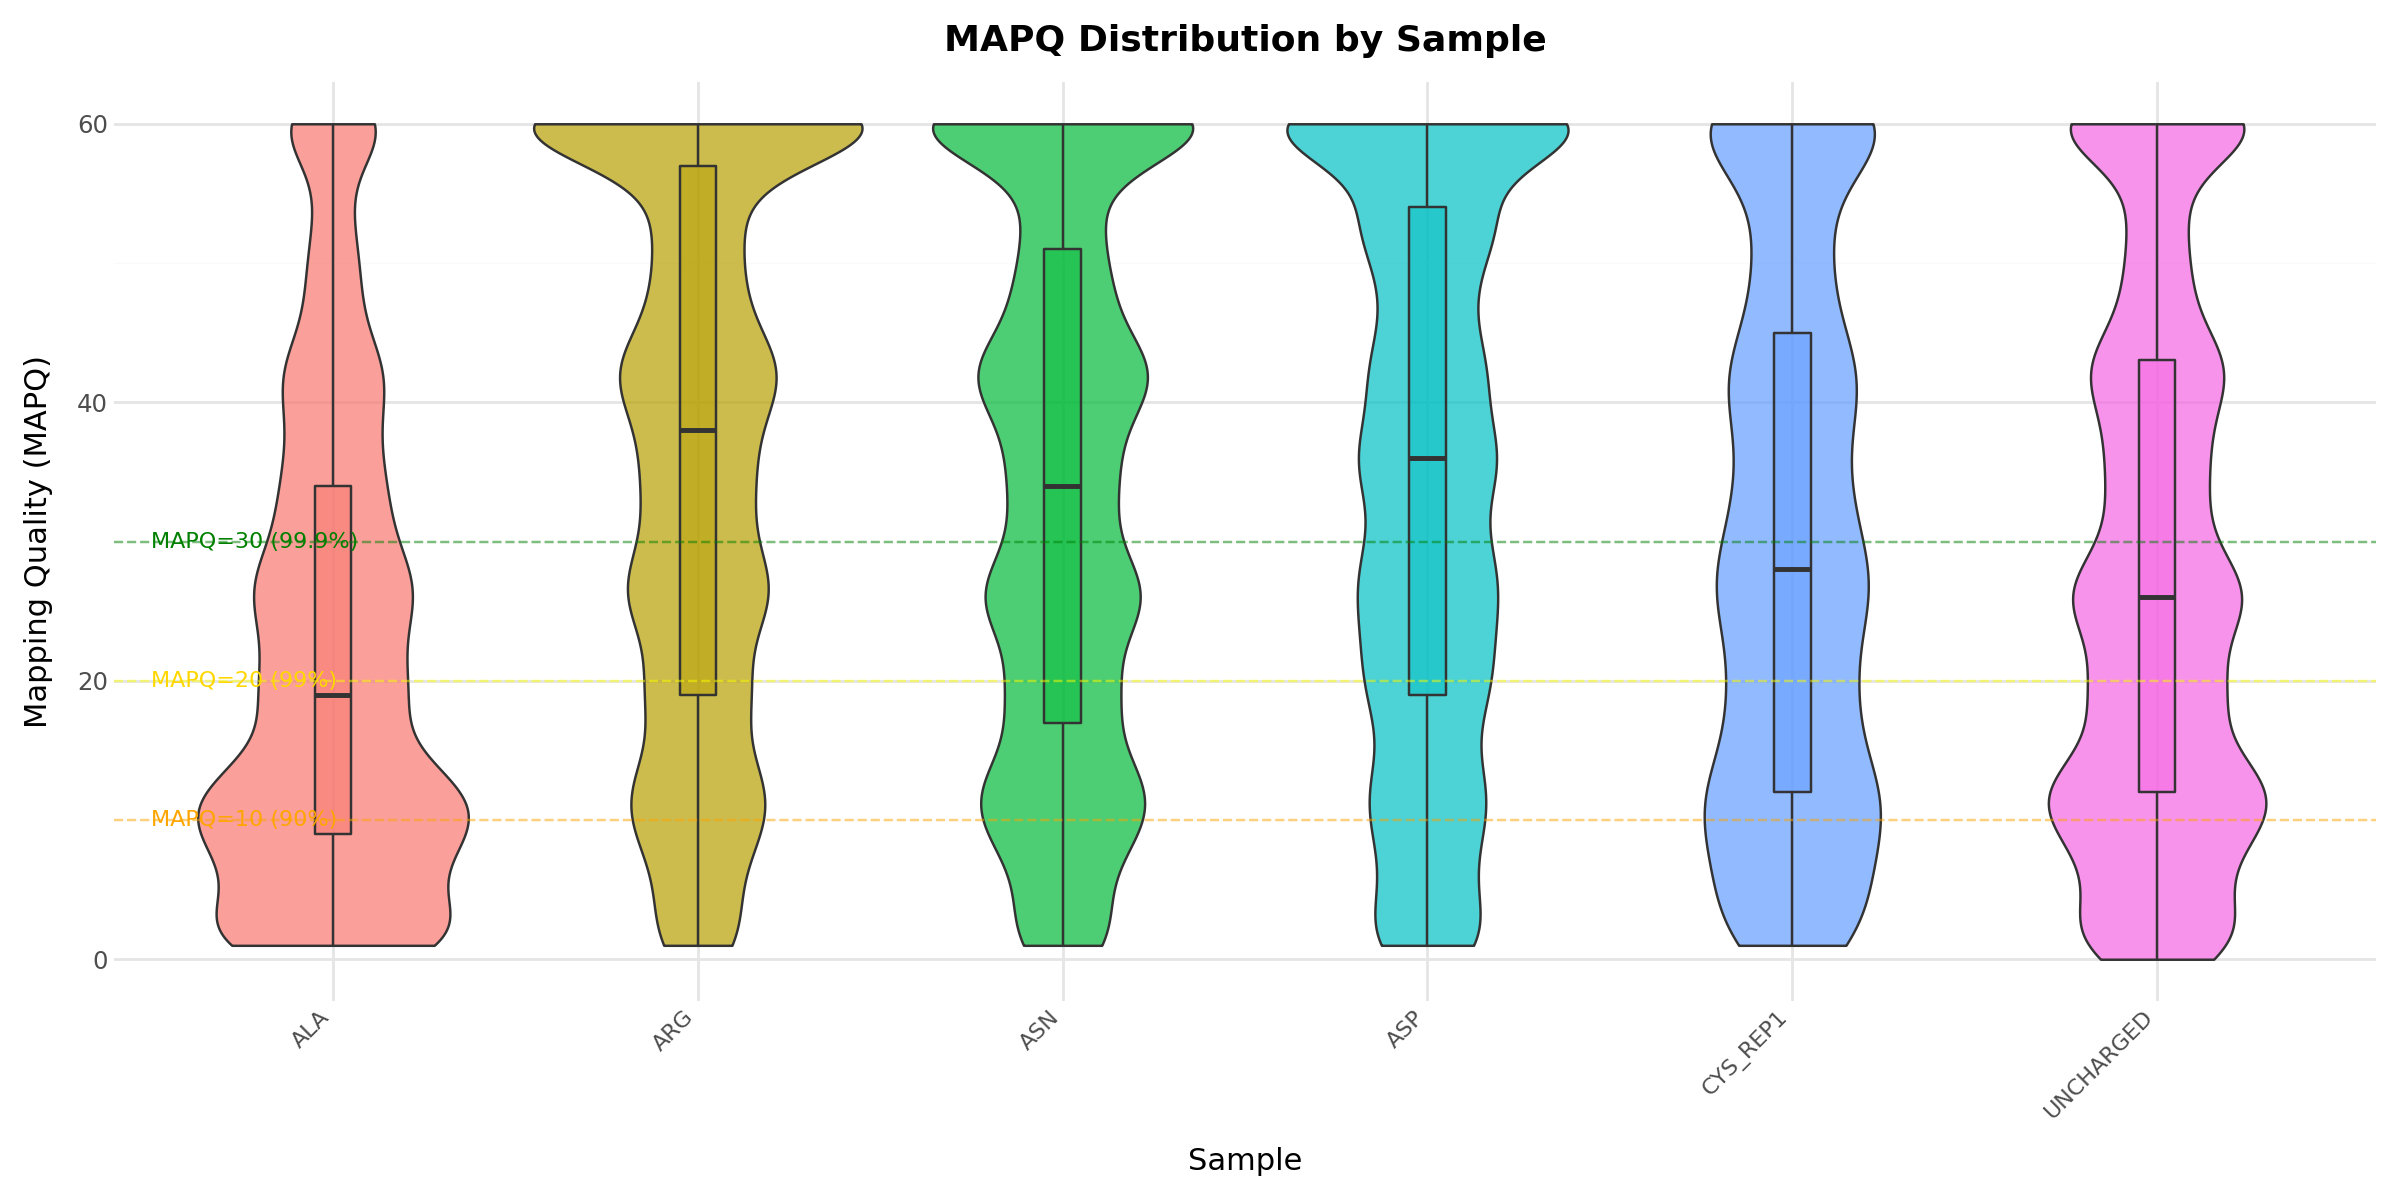

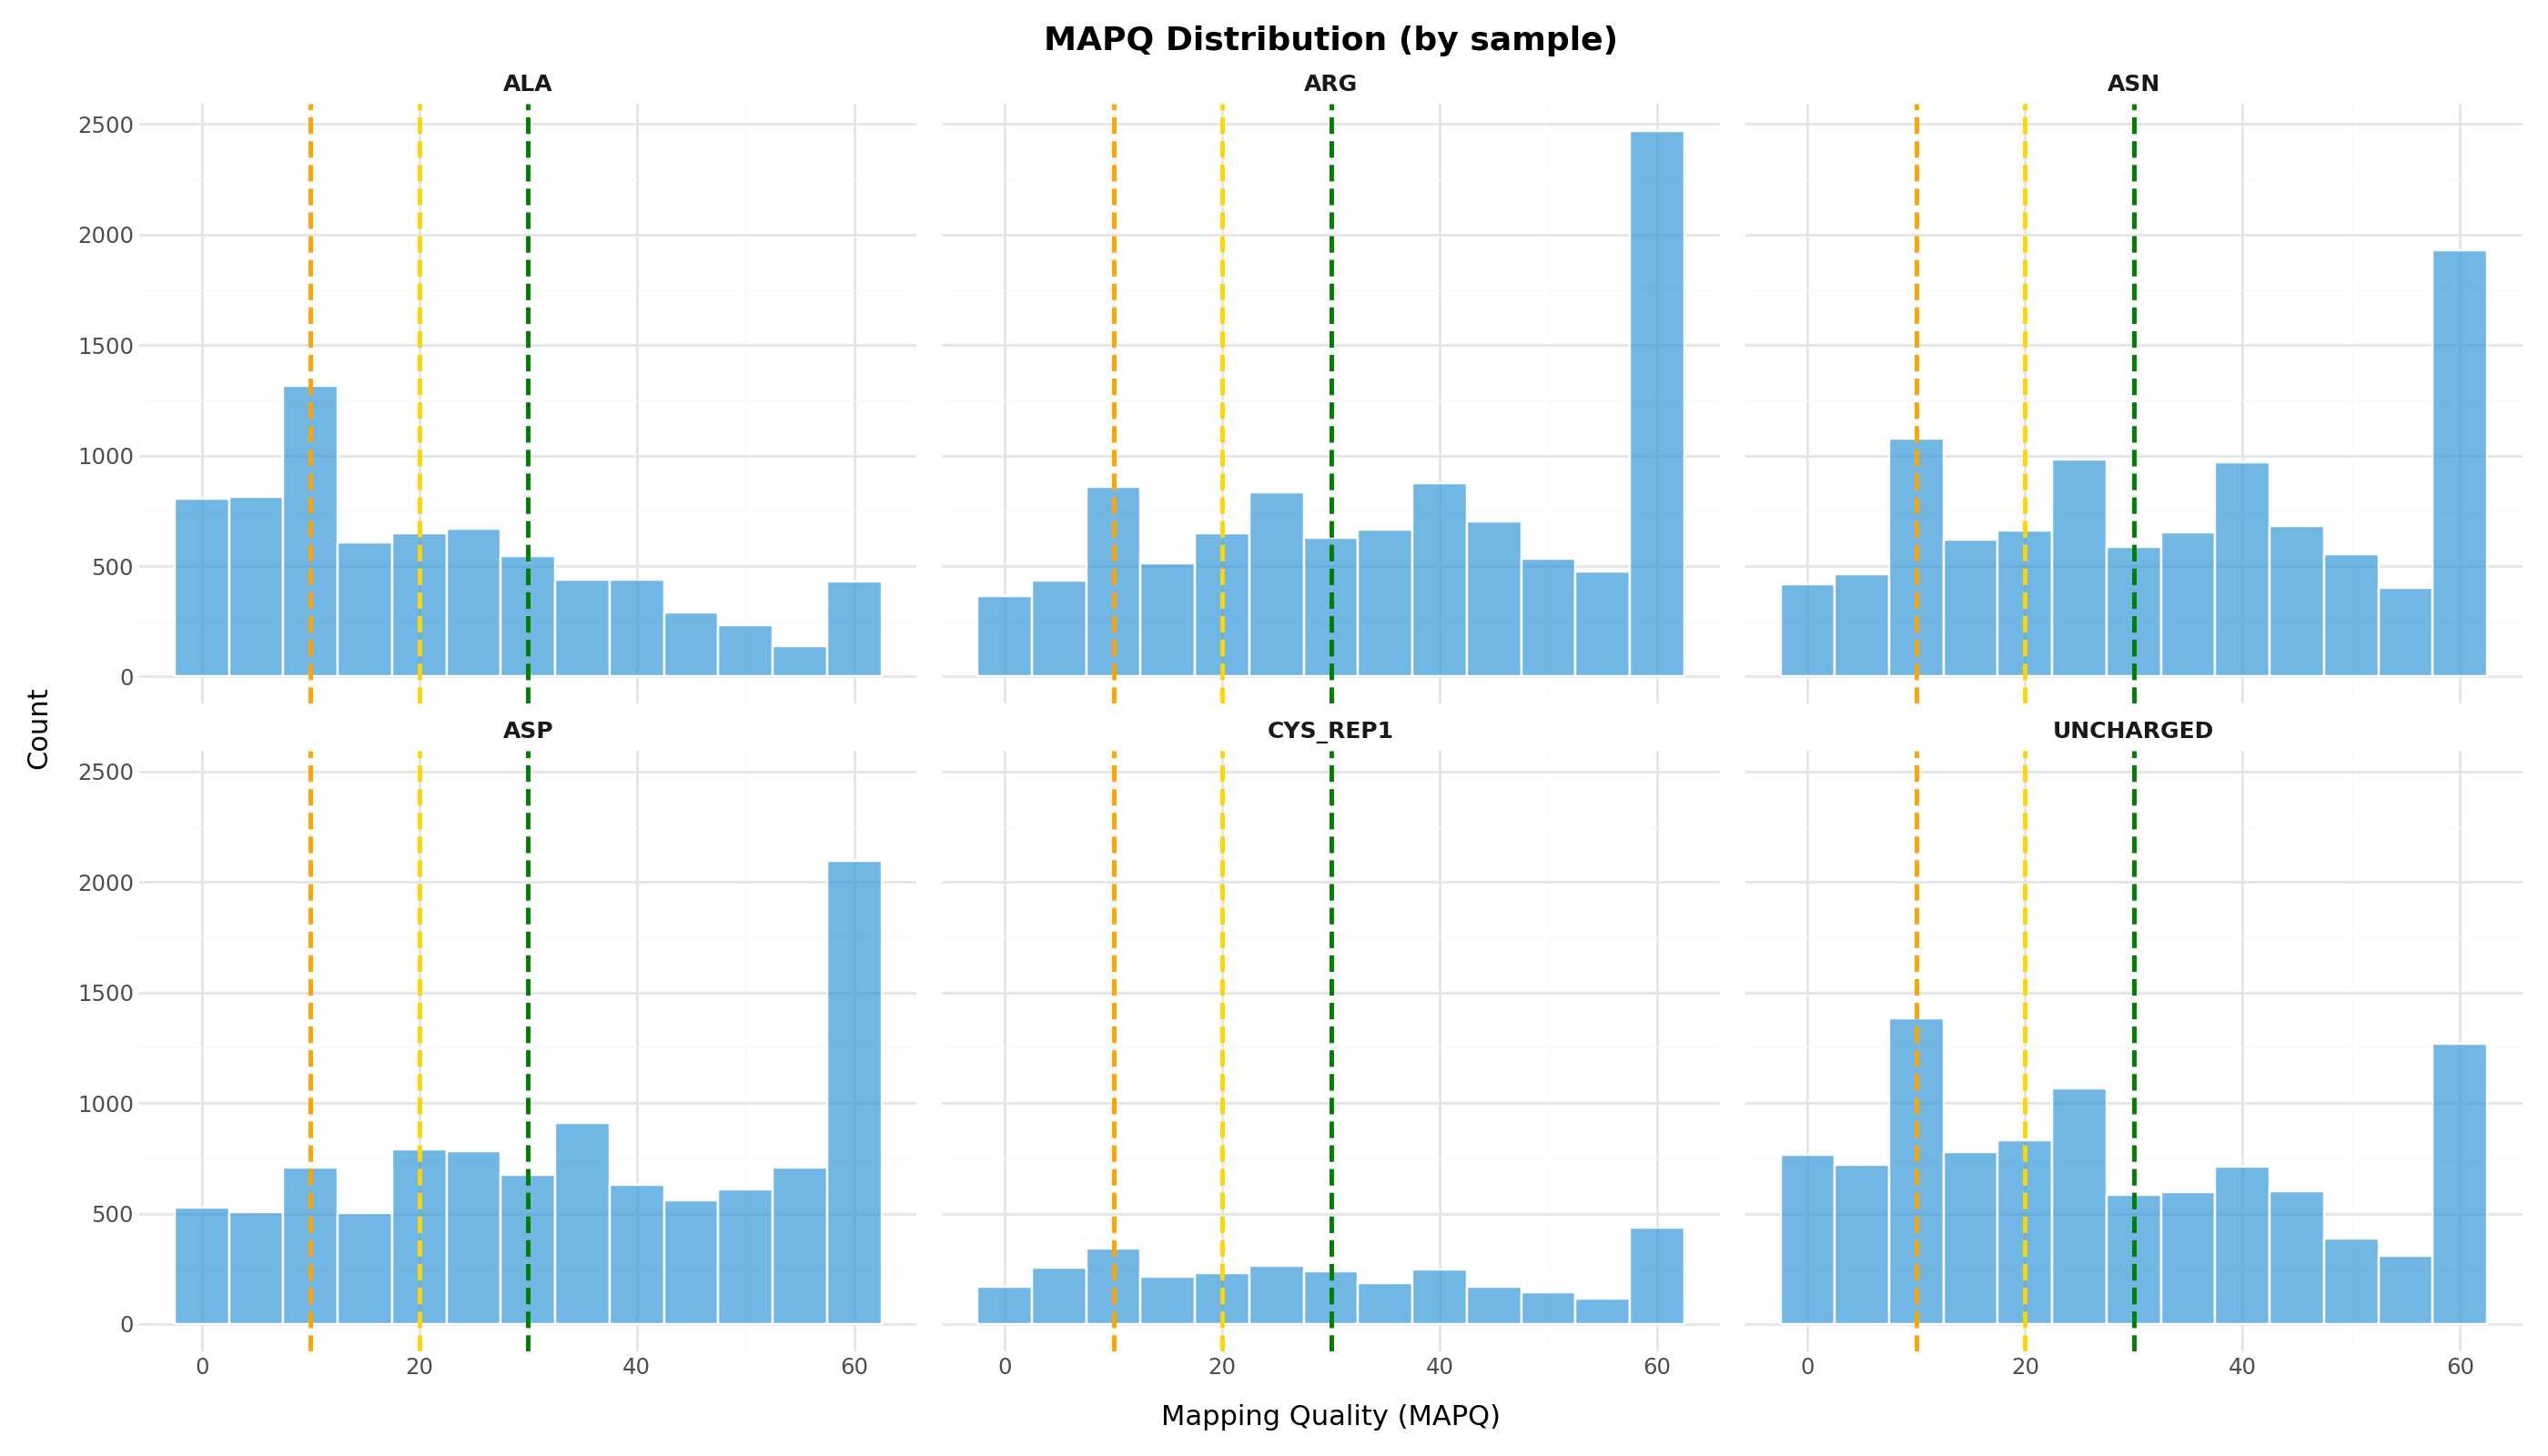


MAPQ THRESHOLD RECOMMENDATIONS

Percentage of reads above threshold:
  MAPQ ≥ 10: 83.3% (90% mapping accuracy)
  MAPQ ≥ 20: 66.1% (99% mapping accuracy)
  MAPQ ≥ 30: 50.1% (99.9% mapping accuracy)

Current MIN_MAPQ setting: 30
→ This will retain ~50.1% of reads

Recommendations:
  • MIN_MAPQ = 10: Keep most reads, moderate quality
  • MIN_MAPQ = 20: Good balance of quality vs quantity
  • MIN_MAPQ = 30: Highest quality, fewer reads (may reduce noise)

  Adjust MIN_MAPQ in the configuration cell above if needed.


In [9]:
# ============================================================================
# MAPQ DISTRIBUTION ANALYSIS
# ============================================================================
# Visualize alignment quality scores to help set MIN_MAPQ threshold

print("=" * 80)
print("ANALYZING MAPQ DISTRIBUTIONS")
print("=" * 80)

mapq_data = []
n_samples_to_check = min(5, len(CHARGED_SAMPLES))  # Check first 5 samples for speed

print(f"\nSampling MAPQ scores from {n_samples_to_check} amino acid samples...")
print("(This helps determine a good quality threshold)")

for aa_sample in CHARGED_SAMPLES[:n_samples_to_check]:
    bam_path = BASE_DIR / PROJECT_NAME / "bam" / "rebasecall" / aa_sample / f"{aa_sample}.aligned.bam"

    if not bam_path.exists():
        print(f"  ⚠️  Skipping {aa_sample}: BAM not found")
        continue

    print(f"  Reading {aa_sample}...")

    # Read MAPQ scores from BAM (sample first 10000 reads for speed)
    bam_reader = BAMReader(bam_path, min_mapq=0)  # No filtering yet

    n_reads = 0
    max_reads = 10000

    with bam_reader:
        for aln in bam_reader.iter_alignments():
            if n_reads >= max_reads:
                break

            if not aln.is_unmapped and aln.mapping_quality is not None:
                mapq_data.append({
                    "sample": aa_sample.replace("_synthetic", "").upper(),
                    "mapq": aln.mapping_quality
                })
                n_reads += 1

# Also check uncharged
uncharged_bam = BASE_DIR / PROJECT_NAME / "bam" / "rebasecall" / UNCHARGED_SAMPLE / f"{UNCHARGED_SAMPLE}.aligned.bam"
if uncharged_bam.exists():
    print(f"  Reading {UNCHARGED_SAMPLE}...")
    bam_reader = BAMReader(uncharged_bam, min_mapq=0)
    n_reads = 0
    with bam_reader:
        for aln in bam_reader.iter_alignments():
            if n_reads >= max_reads:
                break
            if not aln.is_unmapped and aln.mapping_quality is not None:
                mapq_data.append({
                    "sample": "UNCHARGED",
                    "mapq": aln.mapping_quality
                })
                n_reads += 1

mapq_df = pl.DataFrame(mapq_data).to_pandas()

print(f"\n✓ Collected {len(mapq_df)} MAPQ scores from {mapq_df['sample'].nunique()} samples")

# Compute summary statistics
print("\nMAPQ Summary Statistics:")
print(mapq_df.groupby("sample")["mapq"].describe())

# === VIOLIN PLOT ===
plot1 = (
    p9.ggplot(mapq_df, p9.aes(x="sample", y="mapq", fill="sample"))
    + p9.geom_violin(alpha=0.7)
    + p9.geom_boxplot(width=0.1, alpha=0.5)
    + p9.geom_hline(yintercept=10, linetype="dashed", color="orange", alpha=0.5)
    + p9.geom_hline(yintercept=20, linetype="dashed", color="yellow", alpha=0.5)
    + p9.geom_hline(yintercept=30, linetype="dashed", color="green", alpha=0.5)
    + p9.annotate("text", x=0.5, y=10, label="MAPQ=10 (90%)", ha="left", size=8, color="orange")
    + p9.annotate("text", x=0.5, y=20, label="MAPQ=20 (99%)", ha="left", size=8, color="gold")
    + p9.annotate("text", x=0.5, y=30, label="MAPQ=30 (99.9%)", ha="left", size=8, color="green")
    + p9.labs(
        title="MAPQ Distribution by Sample",
        x="Sample",
        y="Mapping Quality (MAPQ)",
        fill="Sample"
    )
    + p9.theme_minimal()
    + p9.theme(
        figure_size=(12, 6),
        plot_title=p9.element_text(size=13, weight="bold"),
        axis_text_x=p9.element_text(angle=45, ha="right", size=8),
        legend_position="none"
    )
)

plot1.show()

# === HISTOGRAM ===
plot2 = (
    p9.ggplot(mapq_df, p9.aes(x="mapq"))
    + p9.geom_histogram(binwidth=5, fill="#3498DB", alpha=0.7, color="white")
    + p9.geom_vline(xintercept=10, linetype="dashed", color="orange", size=1)
    + p9.geom_vline(xintercept=20, linetype="dashed", color="gold", size=1)
    + p9.geom_vline(xintercept=30, linetype="dashed", color="green", size=1)
    + p9.facet_wrap("~sample", ncol=3)
    + p9.labs(
        title="MAPQ Distribution (by sample)",
        x="Mapping Quality (MAPQ)",
        y="Count"
    )
    + p9.theme_minimal()
    + p9.theme(
        figure_size=(14, 8),
        plot_title=p9.element_text(size=13, weight="bold"),
        strip_text=p9.element_text(size=9, weight="bold")
    )
)

plot2.show()

# Recommendations
print("\n" + "=" * 80)
print("MAPQ THRESHOLD RECOMMENDATIONS")
print("=" * 80)

pct_above_10 = (mapq_df["mapq"] >= 10).sum() / len(mapq_df) * 100
pct_above_20 = (mapq_df["mapq"] >= 20).sum() / len(mapq_df) * 100
pct_above_30 = (mapq_df["mapq"] >= 30).sum() / len(mapq_df) * 100

print("\nPercentage of reads above threshold:")
print(f"  MAPQ ≥ 10: {pct_above_10:.1f}% (90% mapping accuracy)")
print(f"  MAPQ ≥ 20: {pct_above_20:.1f}% (99% mapping accuracy)")
print(f"  MAPQ ≥ 30: {pct_above_30:.1f}% (99.9% mapping accuracy)")

print(f"\nCurrent MIN_MAPQ setting: {MIN_MAPQ}")
print(f"→ This will retain ~{(mapq_df['mapq'] >= MIN_MAPQ).sum() / len(mapq_df) * 100:.1f}% of reads")

print("\nRecommendations:")
print("  • MIN_MAPQ = 10: Keep most reads, moderate quality")
print("  • MIN_MAPQ = 20: Good balance of quality vs quantity")
print("  • MIN_MAPQ = 30: Highest quality, fewer reads (may reduce noise)")
print("\n  Adjust MIN_MAPQ in the configuration cell above if needed.")
print("=" * 80)

DWELL TIME DIAGNOSTICS

Sampling dwell times from 3 samples...

  Reading ala_synthetic...

  Reading arg_synthetic...

  Reading asn_synthetic...

✓ Collected 54261 dwell time measurements

DWELL TIME STATISTICS (samples per nucleotide)

Overall:
  Mean:   50.4 samples/nt
  Median: 30.0 samples/nt
  Std:    84.4 samples/nt
  Min:    6 samples/nt
  Max:    2520 samples/nt

Per sample:
  ALA: mean=50.6, median=36.0 samples/nt
  ARG: mean=50.2, median=24.0 samples/nt
  ASN: mean=50.3, median=30.0 samples/nt

SIGNAL WINDOW ESTIMATES

Signal context: 3000 + 3000 = 6000 samples

Estimated nucleotides covered:
  Using mean dwell:   119.2 nt
  Using median dwell: 200.0 nt

K-mer context: ±50 nt = 101 nt total
Expected signal samples needed (using mean dwell):
  5086 samples

✓ SIGNAL_CONTEXT is adequate for KMER_CONTEXT


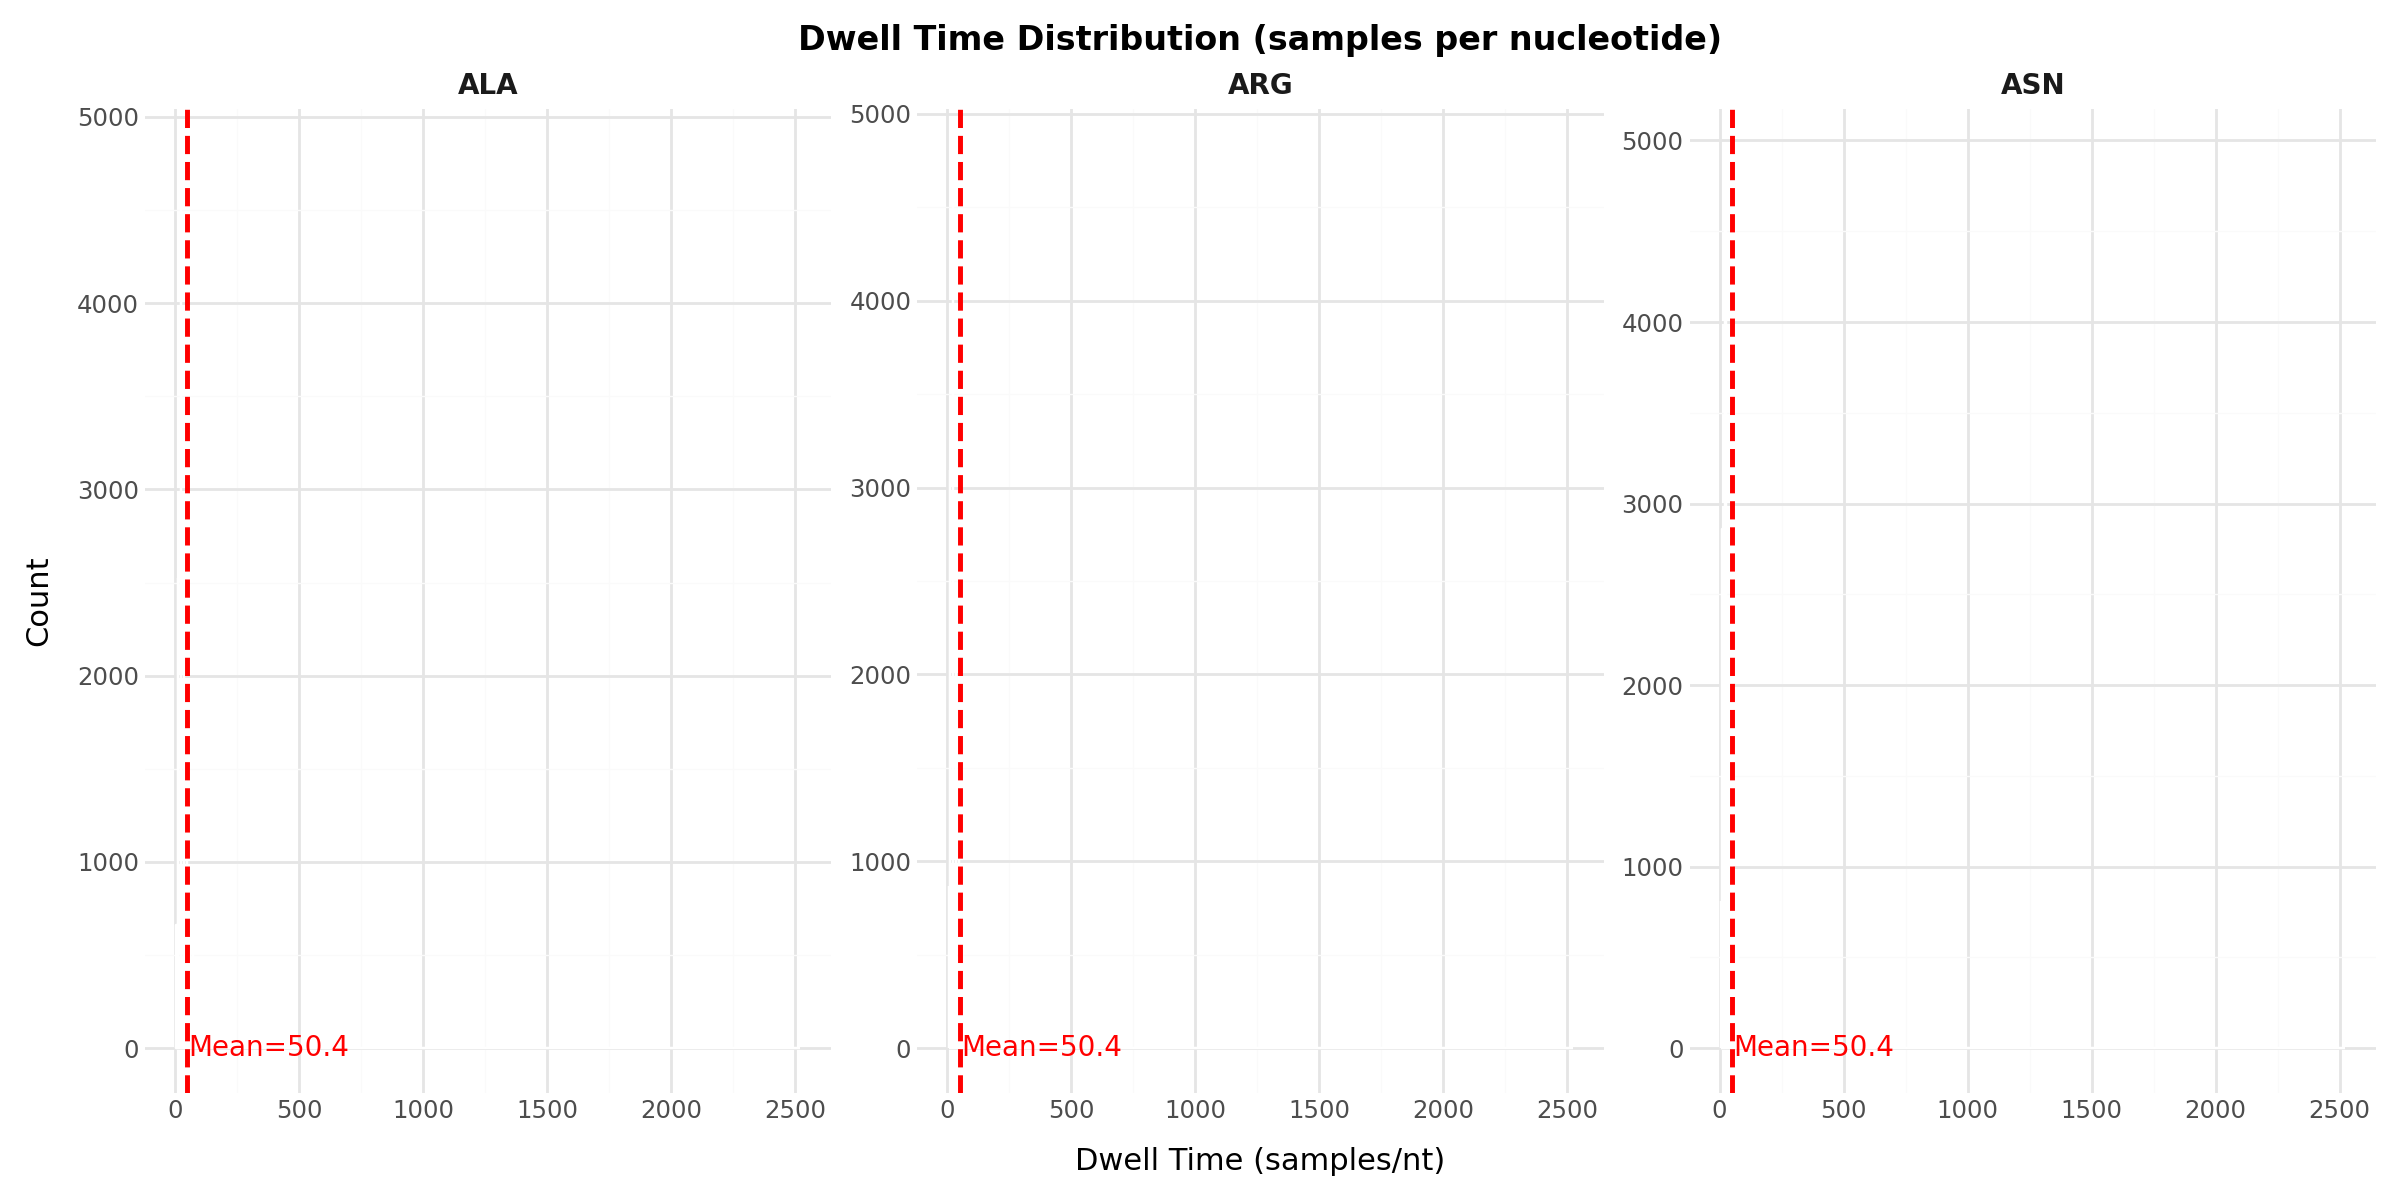

In [10]:
# ============================================================================
# DWELL TIME DIAGNOSTICS
# ============================================================================
# Estimate average dwell time to understand signal-to-nucleotide mapping

print("=" * 80)
print("DWELL TIME DIAGNOSTICS")
print("=" * 80)

dwell_stats = []
n_samples_to_check = min(3, len(CHARGED_SAMPLES))

print(f"\nSampling dwell times from {n_samples_to_check} samples...")

for aa_sample in CHARGED_SAMPLES[:n_samples_to_check]:
    bam_path = BASE_DIR / PROJECT_NAME / "bam" / "rebasecall" / aa_sample / f"{aa_sample}.aligned.bam"

    if not bam_path.exists():
        continue

    print(f"\n  Reading {aa_sample}...")
    bam_reader = BAMReader(bam_path, min_mapq=MIN_MAPQ)

    n_reads = 0
    max_reads = 100

    with bam_reader:
        for aln in bam_reader.iter_alignments():
            if n_reads >= max_reads:
                break

            if aln.is_unmapped or not aln.has_tag("mv"):
                continue

            try:
                move_table = extract_move_table(aln)
                dwells = compute_dwell_times(move_table)

                for dwell in dwells:
                    dwell_stats.append({
                        "sample": aa_sample.replace("_synthetic", "").upper(),
                        "dwell": dwell
                    })

                n_reads += 1
            except Exception:
                continue

dwell_df = pl.DataFrame(dwell_stats).to_pandas()

print(f"\n✓ Collected {len(dwell_df)} dwell time measurements")

# Compute statistics
print("\n" + "=" * 80)
print("DWELL TIME STATISTICS (samples per nucleotide)")
print("=" * 80)

overall_stats = dwell_df["dwell"].describe()
print("\nOverall:")
print(f"  Mean:   {overall_stats['mean']:.1f} samples/nt")
print(f"  Median: {overall_stats['50%']:.1f} samples/nt")
print(f"  Std:    {overall_stats['std']:.1f} samples/nt")
print(f"  Min:    {overall_stats['min']:.0f} samples/nt")
print(f"  Max:    {overall_stats['max']:.0f} samples/nt")

print("\nPer sample:")
for sample in dwell_df["sample"].unique():
    sample_dwells = dwell_df[dwell_df["sample"] == sample]["dwell"]
    print(f"  {sample}: mean={sample_dwells.mean():.1f}, median={sample_dwells.median():.1f} samples/nt")

# Estimate nucleotides per signal window
mean_dwell = overall_stats['mean']
median_dwell = overall_stats['50%']

signal_left, signal_right = SIGNAL_CONTEXT
total_signal = signal_left + signal_right

nt_from_mean = total_signal / mean_dwell
nt_from_median = total_signal / median_dwell

print("\n" + "=" * 80)
print("SIGNAL WINDOW ESTIMATES")
print("=" * 80)
print(f"\nSignal context: {signal_left} + {signal_right} = {total_signal} samples")
print("\nEstimated nucleotides covered:")
print(f"  Using mean dwell:   {nt_from_mean:.1f} nt")
print(f"  Using median dwell: {nt_from_median:.1f} nt")

print(f"\nK-mer context: ±{KMER_CONTEXT} nt = {2*KMER_CONTEXT+1} nt total")
print("Expected signal samples needed (using mean dwell):")
print(f"  {(2*KMER_CONTEXT+1) * mean_dwell:.0f} samples")

if (2*KMER_CONTEXT+1) * mean_dwell > total_signal:
    print("\n⚠️  WARNING: SIGNAL_CONTEXT may be too small!")
    print(f"    Consider increasing to at least {int((2*KMER_CONTEXT+1) * mean_dwell)}")
else:
    print("\n✓ SIGNAL_CONTEXT is adequate for KMER_CONTEXT")

# Histogram of dwell times
plot = (
    p9.ggplot(dwell_df, p9.aes(x="dwell"))
    + p9.geom_histogram(binwidth=1, fill="#3498DB", alpha=0.7, color="white")
    + p9.geom_vline(xintercept=mean_dwell, linetype="dashed", color="red", size=1)
    + p9.annotate("text", x=mean_dwell+5, y=0.9, label=f"Mean={mean_dwell:.1f}", ha="left", color="red", size=10)
    + p9.facet_wrap("~sample", ncol=3, scales="free_y")
    + p9.labs(
        title="Dwell Time Distribution (samples per nucleotide)",
        x="Dwell Time (samples/nt)",
        y="Count"
    )
    + p9.theme_minimal()
    + p9.theme(
        figure_size=(12, 6),
        plot_title=p9.element_text(size=12, weight="bold"),
        strip_text=p9.element_text(size=10, weight="bold")
    )
)

plot.show()

print("=" * 80)

CIGAR ANALYSIS: Motif Region Alignment Patterns

Analyzing motif region: CCATGGC at reference positions 97-104
Position 3 (index 100) is the amino acid attachment site (placeholder 'T')

Sampling from: ala_synthetic.aligned.bam
✓ Analyzed 583 reads spanning motif region

ALIGNMENT PATTERN DISTRIBUTION

Total reads analyzed: 583

Breakdown:
  perfect_match       :    80 ( 13.7%)
  substitution        :     0 (  0.0%)
  insertion           :    57 (  9.8%)
  deletion            :   386 ( 66.2%)
  both_indels         :    60 ( 10.3%)

Total with indels: 503 (86.3%)
Total without indels: 80 (13.7%)


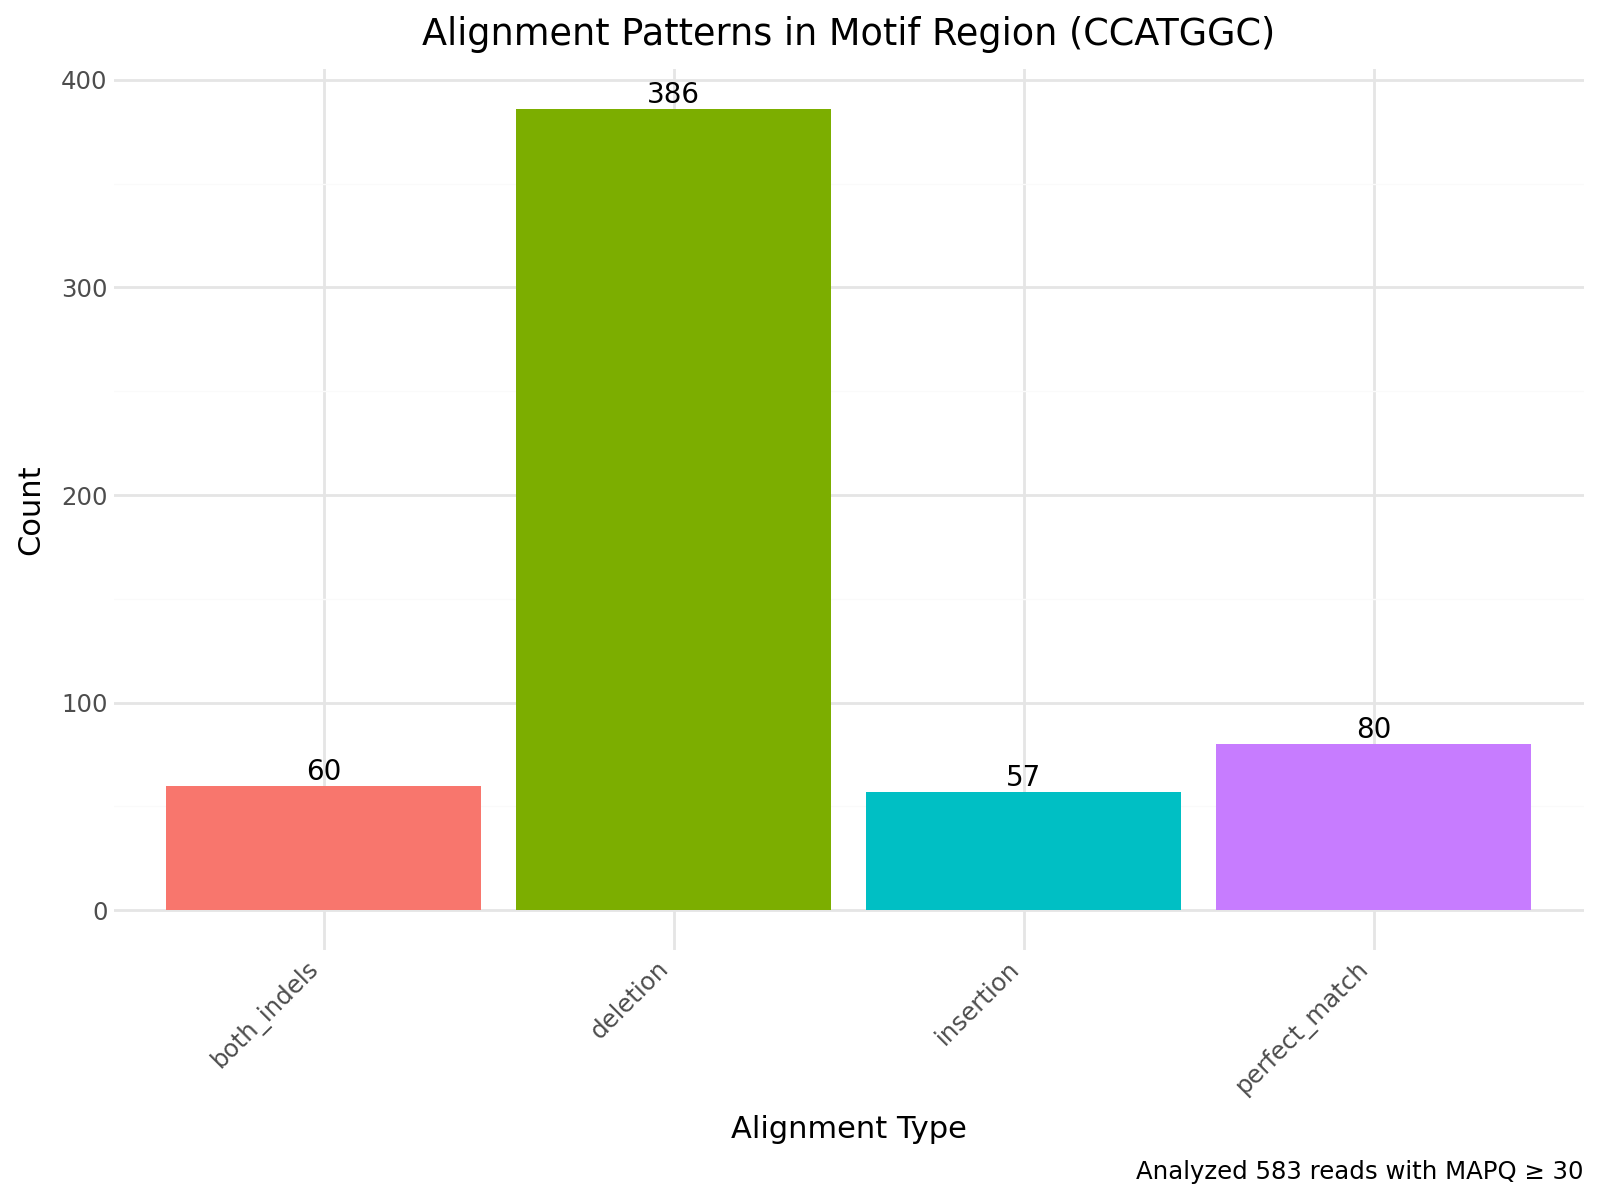


INDEL POSITION DISTRIBUTION

Motif: CCATGGC
Position: 0   1   2   3   4   5   6
          C   C   A   T   G   G   C
                      ^
                      AA attachment site (placeholder)

Total indels found: 823

Indel counts by position:
  Position 0 (C): deletion   =  45
  Position 0 (C): insertion  =   6
  Position 1 (C): deletion   =   9
  Position 1 (C): insertion  =  11
  Position 2 (A): deletion   =  87
  Position 2 (A): insertion  =  28
  Position 3 (T): deletion   = 254
  Position 3 (T): insertion  =  38
  Position 4 (G): deletion   =  20
  Position 4 (G): insertion  =   9
  Position 5 (G): deletion   =   4
  Position 5 (G): insertion  =  20
  Position 6 (C): deletion   =  16
  Position 6 (C): insertion  =  22


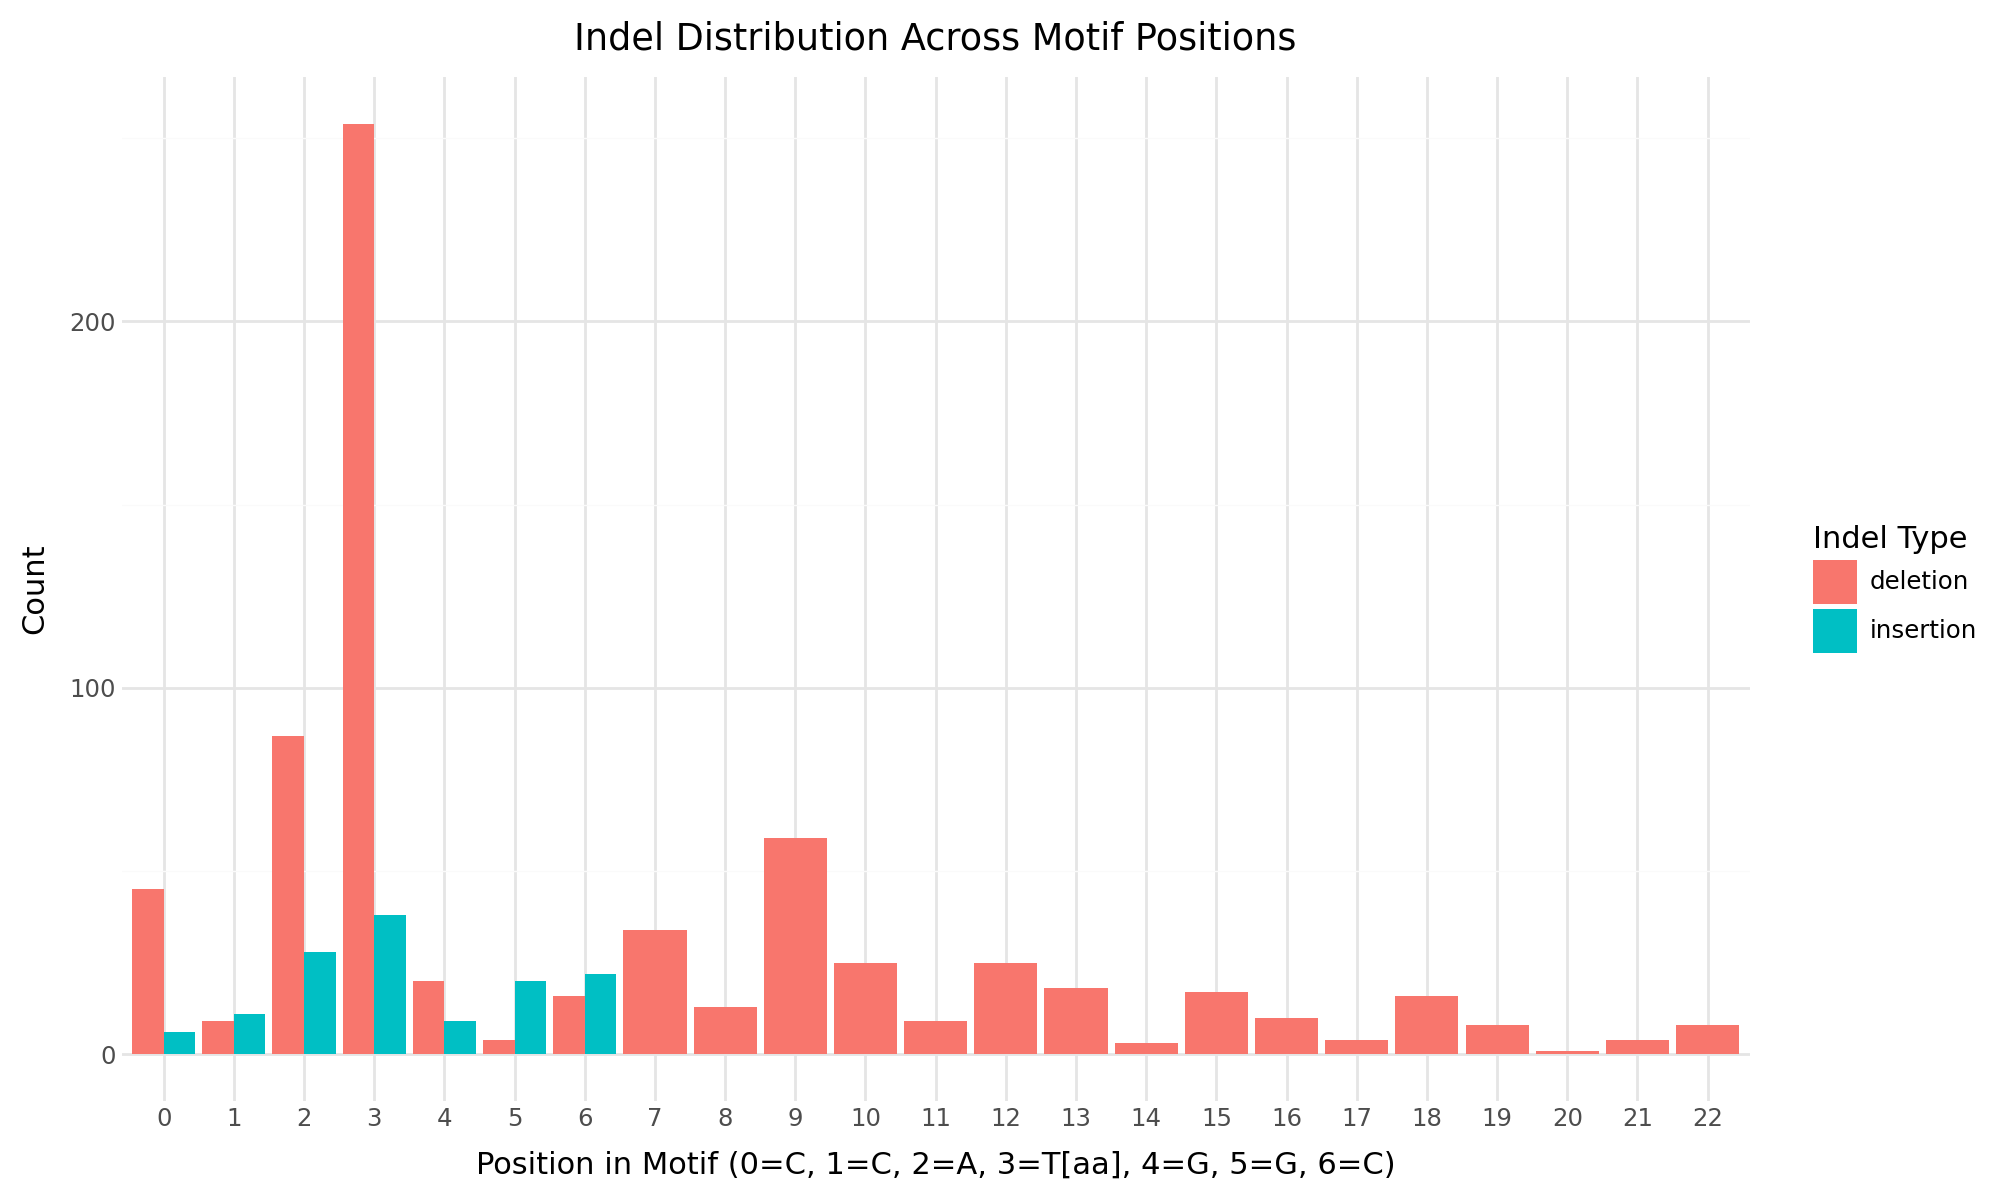


Indels at position 3 (AA site): 292 (35.5% of all indels)

RECOMMENDATIONS FOR MOTIF SEARCH PARAMETERS

⚠ High indel rate (86.3%)
  → Many reads have indels - this is expected near modifications
  → Recommendation: Use skip_indels=False with lenient length check
  → Consider basecalled search (MOTIF_REFERENCE='bam') as alternative

Current setting: skip_indels=False (accepting all indels with ±3bp tolerance)
Expected detection rate: ~13.7% if using skip_indels=True


In [11]:
# ============================================================================
# CIGAR ANALYSIS: Quantify Substitutions vs Indels at Motif Position
# ============================================================================
# Analyze how often reads have substitutions vs indels in the motif region
# This helps decide whether to use skip_indels, allow_edge_indels, or neither

print("=" * 80)
print("CIGAR ANALYSIS: Motif Region Alignment Patterns")
print("=" * 80)

# Motif position in reference (CCATGGC at position 97-104)
MOTIF_REF_START = 97
MOTIF_REF_END = 104
MOTIF_LEN = MOTIF_REF_END - MOTIF_REF_START

print(f"\nAnalyzing motif region: {MOTIF} at reference positions {MOTIF_REF_START}-{MOTIF_REF_END}")
print(f"Position 3 (index 100) is the amino acid attachment site (placeholder 'T')")

cigar_stats = []
indel_positions = []  # Track where indels occur within motif

# Sample from one BAM file
sample_bam = BASE_DIR / PROJECT_NAME / "bam" / "rebasecall" / CHARGED_SAMPLES[0] / f"{CHARGED_SAMPLES[0]}.aligned.bam"
print(f"\nSampling from: {sample_bam.name}")

bam_reader = BAMReader(sample_bam, min_mapq=MIN_MAPQ)
n_analyzed = 0
max_reads = 1000

with bam_reader:
    for aln in bam_reader.iter_alignments():
        if n_analyzed >= max_reads:
            break

        # Skip reads that don't span the motif region
        if aln.reference_start > MOTIF_REF_START or aln.reference_end < MOTIF_REF_END:
            continue

        if aln.cigartuples is None:
            continue

        # Parse CIGAR to find operations in motif region
        ref_pos = aln.reference_start
        has_insertion = False
        has_deletion = False
        has_mismatch = False

        for op, length in aln.cigartuples:
            # Check if this operation overlaps motif region
            if op in (0, 7, 8):  # M/=/X (match/equal/diff)
                # Check for mismatches in motif region
                if op == 8 and ref_pos < MOTIF_REF_END and ref_pos + length > MOTIF_REF_START:
                    has_mismatch = True
                ref_pos += length
            elif op == 1:  # I (insertion)
                if ref_pos >= MOTIF_REF_START and ref_pos < MOTIF_REF_END:
                    has_insertion = True
                    # Track position within motif (0-6)
                    motif_offset = ref_pos - MOTIF_REF_START
                    indel_positions.append({'type': 'insertion', 'position': motif_offset})
            elif op == 2:  # D (deletion)
                if ref_pos >= MOTIF_REF_START and ref_pos + length > MOTIF_REF_START:
                    has_deletion = True
                    # Track position within motif
                    motif_offset = max(0, ref_pos - MOTIF_REF_START)
                    indel_positions.append({'type': 'deletion', 'position': motif_offset})
                ref_pos += length
            elif op == 4:  # S (soft clip)
                pass

        # Classify alignment
        if has_insertion or has_deletion:
            if has_insertion and has_deletion:
                alignment_type = 'both_indels'
            elif has_insertion:
                alignment_type = 'insertion'
            else:
                alignment_type = 'deletion'
        elif has_mismatch:
            alignment_type = 'substitution'
        else:
            alignment_type = 'perfect_match'

        cigar_stats.append({'alignment_type': alignment_type})
        n_analyzed += 1

print(f"✓ Analyzed {n_analyzed} reads spanning motif region")

# Convert to DataFrame
cigar_df = pl.DataFrame(cigar_stats).to_pandas()
indel_df = pl.DataFrame(indel_positions).to_pandas() if indel_positions else pd.DataFrame()

# Summary statistics
print("\n" + "=" * 80)
print("ALIGNMENT PATTERN DISTRIBUTION")
print("=" * 80)

counts = cigar_df['alignment_type'].value_counts()
total = len(cigar_df)

print(f"\nTotal reads analyzed: {total}")
print("\nBreakdown:")
for atype in ['perfect_match', 'substitution', 'insertion', 'deletion', 'both_indels']:
    count = counts.get(atype, 0)
    pct = count / total * 100
    print(f"  {atype:20s}: {count:5d} ({pct:5.1f}%)")

# Calculate indel rate
has_indel = cigar_df['alignment_type'].isin(['insertion', 'deletion', 'both_indels']).sum()
indel_rate = has_indel / total * 100
print(f"\nTotal with indels: {has_indel} ({indel_rate:.1f}%)")
print(f"Total without indels: {total - has_indel} ({100 - indel_rate:.1f}%)")

# Visualize alignment types
plot_df = cigar_df['alignment_type'].value_counts().reset_index()
plot_df.columns = ['alignment_type', 'count']
plot_df['percentage'] = plot_df['count'] / total * 100

plot1 = (
    p9.ggplot(plot_df, p9.aes(x='alignment_type', y='count', fill='alignment_type'))
    + p9.geom_col()
    + p9.geom_text(p9.aes(label='count'), va='bottom', size=10)
    + p9.labs(
        title=f'Alignment Patterns in Motif Region ({MOTIF})',
        x='Alignment Type',
        y='Count',
        caption=f'Analyzed {total} reads with MAPQ ≥ {MIN_MAPQ}'
    )
    + p9.theme_minimal()
    + p9.theme(axis_text_x=p9.element_text(rotation=45, ha='right'),
            legend_position='none',
            figure_size=(8, 6))
)
plot1.show()

# Analyze indel positions
if len(indel_df) > 0:
    print("\n" + "=" * 80)
    print("INDEL POSITION DISTRIBUTION")
    print("=" * 80)
    print(f"\nMotif: {MOTIF}")
    print("Position: 0   1   2   3   4   5   6")
    print("          C   C   A   T   G   G   C")
    print("                      ^")
    print("                      AA attachment site (placeholder)")

    print(f"\nTotal indels found: {len(indel_df)}")

    # Count by position
    pos_counts = indel_df.groupby(['position', 'type']).size().reset_index(name='count')
    print("\nIndel counts by position:")
    for pos in range(MOTIF_LEN):
        pos_data = pos_counts[pos_counts['position'] == pos]
        if len(pos_data) > 0:
            for _, row in pos_data.iterrows():
                print(f"  Position {pos} ({MOTIF[pos]}): {row['type']:10s} = {row['count']:3d}")

    # Visualize indel positions
    plot2 = (
        p9.ggplot(pos_counts, p9.aes(x='factor(position)', y='count', fill='type'))
        + p9.geom_col(position='dodge')
        + p9.labs(
            title='Indel Distribution Across Motif Positions',
            x='Position in Motif (0=C, 1=C, 2=A, 3=T[aa], 4=G, 5=G, 6=C)',
            y='Count',
            fill='Indel Type'
        )
        + p9.theme_minimal()
        + p9.theme(figure_size=(10, 6))
    )
    plot2.show()

    # Check if indels are concentrated at position 3 (AA site)
    pos3_indels = len(indel_df[indel_df['position'] == 3])
    pos3_pct = pos3_indels / len(indel_df) * 100 if len(indel_df) > 0 else 0

    print(f"\nIndels at position 3 (AA site): {pos3_indels} ({pos3_pct:.1f}% of all indels)")
else:
    print("\n✓ No indels found in motif region!")

# Recommendations
print("\n" + "=" * 80)
print("RECOMMENDATIONS FOR MOTIF SEARCH PARAMETERS")
print("=" * 80)

if indel_rate < 5:
    print(f"\n✓ Low indel rate ({indel_rate:.1f}%)")
    print("  → Recommendation: Use skip_indels=True for cleanest data")
    print("  → This will keep ~95% of reads with high quality alignments")
elif indel_rate < 20:
    print(f"\n⚠ Moderate indel rate ({indel_rate:.1f}%)")
    if len(indel_df) > 0 and pos3_pct > 50:
        print("  → Indels concentrated at AA position (expected!)")
        print("  → Recommendation: Use allow_edge_indels=True")
        print("  → This accepts indels in flanking bases but rejects at core AA site")
    else:
        print("  → Indels scattered across motif")
        print("  → Recommendation: Use skip_indels=False with lenient length check")
        print("  → This maximizes data while accepting some alignment variations")
else:
    print(f"\n⚠ High indel rate ({indel_rate:.1f}%)")
    print("  → Many reads have indels - this is expected near modifications")
    print("  → Recommendation: Use skip_indels=False with lenient length check")
    print("  → Consider basecalled search (MOTIF_REFERENCE='bam') as alternative")

print("\nCurrent setting: skip_indels=False (accepting all indels with ±3bp tolerance)")
print(f"Expected detection rate: ~{100 - indel_rate:.1f}% if using skip_indels=True")
print("=" * 80)


In [ ]:
def extract_wide_window_features(pod5_path, bam_path, label_name, max_reads=500, reference_fasta=None):
    """
    Extract wide-window features for offset analysis.

    Returns:
        List of dicts with features at each position relative to motif.
    """
    print(f"\nExtracting features from {label_name}...")
    print(f"  POD5: {pod5_path}")
    print(f"  BAM:  {bam_path}")

    # Load reference sequences and create motif searcher
    reference_sequences = get_reference_sequences(bam_path, reference_fasta)
    print(f"  Loaded {len(reference_sequences)} reference sequences")

    motif_searcher = get_motif_searcher(
        mode=MOTIF_REFERENCE,
        reference_sequences=reference_sequences,
        skip_indels=True,
        debug=True,
        allow_edge_indels=False
    )

    chunks = []
    bam_reader = BAMReader(bam_path, min_mapq=MIN_MAPQ)
    pod5_reader = POD5Reader(pod5_path)

    n_processed = 0
    n_with_motif = 0
    n_errors = 0

    with bam_reader, pod5_reader:
        for aln in bam_reader.iter_alignments():
            if len(chunks) >= max_reads:
                break

            n_processed += 1

            if aln.is_unmapped or not aln.has_tag("mv") or aln.query_name is None:
                continue

            if aln.query_sequence is None:
                continue

            try:
                # Find motif positions using motif searcher
                motif_positions = motif_searcher.find_motif_positions(
                    read_id=aln.query_name,
                    sequence=aln.query_sequence,
                    alignment=aln,
                    motif=MOTIF
                )

                if not motif_positions:
                    continue

                n_with_motif += 1

                # Get signal and features
                signal, _ = pod5_reader.get_signal(aln.query_name)
                signal_norm, _ = normalize_signal(signal, method="median_mad")

                move_table = extract_move_table(aln)
                seq_to_sig_map = move_table.to_seq_to_sig_map()

                # Compute dwell times and signal features
                dwells = compute_dwell_times(move_table)
                signal_features = compute_signal_features(signal_norm, seq_to_sig_map)

                # Extract wide window around each motif occurrence
                for motif_pos in motif_positions:
                    focus_pos = motif_pos + MOTIF_OFFSET

                    # Check boundaries
                    start_pos = focus_pos - KMER_CONTEXT
                    end_pos = focus_pos + KMER_CONTEXT + 1

                    if start_pos < 0 or end_pos > len(dwells):
                        continue

                    # Extract features across window
                    chunk = {
                        "read_id": aln.query_name,
                        "label": label_name,
                        "motif_pos": motif_pos,
                        "focus_pos": focus_pos,
                        "sequence": aln.query_sequence[start_pos:end_pos],
                        "dwells": dwells[start_pos:end_pos],
                        "signal_mean": signal_features["level_mean"][start_pos:end_pos],
                        "signal_std": signal_features["level_std"][start_pos:end_pos],
                        "signal_median": signal_features["level_median"][start_pos:end_pos],
                    }
                    chunks.append(chunk)

                    if len(chunks) >= max_reads:
                        break

            except Exception as e:
                n_errors += 1
                # Suppress individual warnings, report summary later
                continue

    if n_errors > 0:
        print(f"  Errors: {n_errors} reads failed ({n_errors/n_processed*100:.1f}%)")

    print(f"  Processed {n_processed} alignments")
    print(f"  Found motif in {n_with_motif} reads")
    print(f"  Extracted {len(chunks)} wide-window chunks")


    # Print motif searcher statistics
    if hasattr(motif_searcher, "get_stats"):
        stats = motif_searcher.get_stats()
        print(f"  Motif search stats:")
        print(f"    Motifs in reference: {stats['motifs_in_reference']}")
        print(f"    Failed CIGAR mapping: {stats['failed_cigar_mapping']}")
        print(f"    Failed indels: {stats['failed_indels']}")
        print(f"    Failed length check: {stats['failed_length_check']}")
        print(f"    Successful: {stats['successful']}")
    return chunks


# Extract features for all samples
print("=" * 80)
print("EXTRACTING WIDE-WINDOW FEATURES")
print("=" * 80)

all_chunks = {}

# Extract uncharged once
uncharged_pod5 = BASE_DIR / PROJECT_NAME / "pod5" / UNCHARGED_SAMPLE / f"{UNCHARGED_SAMPLE}.pod5"
uncharged_bam = BASE_DIR / PROJECT_NAME / "bam" / "rebasecall" / UNCHARGED_SAMPLE / f"{UNCHARGED_SAMPLE}.aligned.bam"

print("\nExtracting uncharged control...")
uncharged_chunks = extract_wide_window_features(
    uncharged_pod5, uncharged_bam, "uncharged",
    max_reads=MAX_READS_PER_CLASS,
    reference_fasta=REFERENCE_FASTA
)
all_chunks["uncharged"] = uncharged_chunks

# Extract each charged amino acid
for aa_sample in CHARGED_SAMPLES:
    charged_pod5 = BASE_DIR / PROJECT_NAME / "pod5" / aa_sample / f"{aa_sample}.pod5"
    charged_bam = BASE_DIR / PROJECT_NAME / "bam" / "rebasecall" / aa_sample / f"{aa_sample}.aligned.bam"

    charged_chunks = extract_wide_window_features(
        charged_pod5, charged_bam, aa_sample,
        max_reads=MAX_READS_PER_CLASS,
        reference_fasta=REFERENCE_FASTA
    )
    all_chunks[aa_sample] = charged_chunks

total_chunks = sum(len(chunks) for chunks in all_chunks.values())
print(f"\n✓ Total chunks extracted: {total_chunks}")
print(f"  Samples: {list(all_chunks.keys())}")

No reference sequences found in BAM @SQ header


EXTRACTING WIDE-WINDOW FEATURES

Extracting uncharged control...

Extracting features from uncharged...
  POD5: /scratch/alpine/jhesselberth@xsede.org/leech/synthetic-trna/pod5/uncharged_synthetic/uncharged_synthetic.pod5
  BAM:  /scratch/alpine/jhesselberth@xsede.org/leech/synthetic-trna/bam/rebasecall/uncharged_synthetic/uncharged_synthetic.aligned.bam
  Loaded 1 reference sequences


No reference sequences found in BAM @SQ header


  Errors: 132 reads failed (0.7%)
  Processed 17840 alignments
  Found motif in 436 reads
  Extracted 123 wide-window chunks
  Motif search stats:
    Motifs in reference: 12091
    Failed CIGAR mapping: 421
    Failed indels: 11079
    Failed length check: 155
    Successful: 436

Extracting features from ala_synthetic...
  POD5: /scratch/alpine/jhesselberth@xsede.org/leech/synthetic-trna/pod5/ala_synthetic/ala_synthetic.pod5
  BAM:  /scratch/alpine/jhesselberth@xsede.org/leech/synthetic-trna/bam/rebasecall/ala_synthetic/ala_synthetic.aligned.bam
  Loaded 1 reference sequences


No reference sequences found in BAM @SQ header


...

  Errors: 47 reads failed (0.2%)
  Processed 22088 alignments
  Found motif in 1147 reads
  Extracted 500 wide-window chunks
  Motif search stats:
    Motifs in reference: 6221
    Failed CIGAR mapping: 562
    Failed indels: 1284
    Failed length check: 3228
    Successful: 1147

Extracting features from trp_synthetic...
  POD5: /scratch/alpine/jhesselberth@xsede.org/leech/synthetic-trna/pod5/trp_synthetic/trp_synthetic.pod5
  BAM:  /scratch/alpine/jhesselberth@xsede.org/leech/synthetic-trna/bam/rebasecall/trp_synthetic/trp_synthetic.aligned.bam
  Loaded 1 reference sequences


No reference sequences found in BAM @SQ header


  Errors: 7 reads failed (0.1%)
  Processed 10612 alignments
  Found motif in 826 reads
  Extracted 500 wide-window chunks
  Motif search stats:
    Motifs in reference: 2255
    Failed CIGAR mapping: 239
    Failed indels: 710
    Failed length check: 480
    Successful: 826

Extracting features from tyr_synthetic...
  POD5: /scratch/alpine/jhesselberth@xsede.org/leech/synthetic-trna/pod5/tyr_synthetic/tyr_synthetic.pod5
  BAM:  /scratch/alpine/jhesselberth@xsede.org/leech/synthetic-trna/bam/rebasecall/tyr_synthetic/tyr_synthetic.aligned.bam
  Loaded 1 reference sequences


No reference sequences found in BAM @SQ header


  Errors: 23 reads failed (0.1%)
  Processed 17171 alignments
  Found motif in 1134 reads
  Extracted 500 wide-window chunks
  Motif search stats:
    Motifs in reference: 4655
    Failed CIGAR mapping: 661
    Failed indels: 1134
    Failed length check: 1726
    Successful: 1134

Extracting features from val_synthetic...
  POD5: /scratch/alpine/jhesselberth@xsede.org/leech/synthetic-trna/pod5/val_synthetic/val_synthetic.pod5
  BAM:  /scratch/alpine/jhesselberth@xsede.org/leech/synthetic-trna/bam/rebasecall/val_synthetic/val_synthetic.aligned.bam
  Loaded 1 reference sequences
  Errors: 22 reads failed (0.3%)
  Processed 8474 alignments
  Found motif in 841 reads
  Extracted 500 wide-window chunks
  Motif search stats:
    Motifs in reference: 1934
    Failed CIGAR mapping: 255
    Failed indels: 521
    Failed length check: 317
    Successful: 841

✓ Total chunks extracted: 8785
  Samples: ['uncharged', 'ala_synthetic', 'arg_synthetic', 'asn_synthetic', 'asp_synthetic', 'cys_syntheti

## Step 2: Compute Position-Wise Statistics

Aggregate features across all reads to compute mean and std at each position relative to the motif.

In [14]:
def aggregate_position_wise_features(chunks, label):
    """
    Aggregate features across all chunks to get position-wise statistics.

    Returns:
        DataFrame with columns: position, feature, mean, std, sem, label
    """
    print(f"\nAggregating features for {label} ({len(chunks)} chunks)...")

    # Stack all features into arrays
    window_size = 2 * KMER_CONTEXT + 1

    dwells_matrix = np.array([c["dwells"] for c in chunks if len(c["dwells"]) == window_size])
    signal_mean_matrix = np.array([c["signal_mean"] for c in chunks if len(c["signal_mean"]) == window_size])
    signal_std_matrix = np.array([c["signal_std"] for c in chunks if len(c["signal_std"]) == window_size])

    print(f"  Valid chunks after filtering: {len(dwells_matrix)}")

    # Compute position-wise statistics
    positions = np.arange(-KMER_CONTEXT, KMER_CONTEXT + 1)  # Relative to motif focus

    data = []

    for pos_idx, pos in enumerate(positions):
        # Dwell
        data.append({
            "position": pos,
            "feature": "dwell_time",
            "mean": np.mean(dwells_matrix[:, pos_idx]),
            "std": np.std(dwells_matrix[:, pos_idx]),
            "sem": stats.sem(dwells_matrix[:, pos_idx]),
            "label": label,
        })

        # Signal mean
        data.append({
            "position": pos,
            "feature": "signal_mean",
            "mean": np.mean(signal_mean_matrix[:, pos_idx]),
            "std": np.std(signal_mean_matrix[:, pos_idx]),
            "sem": stats.sem(signal_mean_matrix[:, pos_idx]),
            "label": label,
        })

        # Signal std (variability)
        data.append({
            "position": pos,
            "feature": "signal_variability",
            "mean": np.mean(signal_std_matrix[:, pos_idx]),
            "std": np.std(signal_std_matrix[:, pos_idx]),
            "sem": stats.sem(signal_std_matrix[:, pos_idx]),
            "label": label,
        })

    return pl.DataFrame(data)


# Aggregate for all samples
print("=" * 80)
print("COMPUTING POSITION-WISE STATISTICS")
print("=" * 80)

all_stats_list = []

for sample_name, chunks in all_chunks.items():
    sample_stats = aggregate_position_wise_features(chunks, sample_name)
    all_stats_list.append(sample_stats)

# Combine all
all_stats = pl.concat(all_stats_list)

print(f"\n✓ Aggregated statistics: {len(all_stats)} rows")
print(f"  Samples: {all_stats['label'].unique().to_list()}")
print(f"  Features: {all_stats['feature'].unique().to_list()}")
print(f"  Position range: [{all_stats['position'].min()}, {all_stats['position'].max()}]")

# Preview
print("\nPreview (first 10 rows):")
print(all_stats.head(10))

COMPUTING POSITION-WISE STATISTICS

Aggregating features for uncharged (123 chunks)...
  Valid chunks after filtering: 123

Aggregating features for ala_synthetic (57 chunks)...
  Valid chunks after filtering: 57

Aggregating features for arg_synthetic (261 chunks)...
  Valid chunks after filtering: 261

Aggregating features for asn_synthetic (365 chunks)...
  Valid chunks after filtering: 365

Aggregating features for asp_synthetic (500 chunks)...
  Valid chunks after filtering: 500

Aggregating features for cys_synthetic_rep1 (69 chunks)...
  Valid chunks after filtering: 69

Aggregating features for cys_synthetic_rep2 (82 chunks)...
  Valid chunks after filtering: 82

Aggregating features for gln_synthetic (500 chunks)...
  Valid chunks after filtering: 500

Aggregating features for glu_synthetic (500 chunks)...
  Valid chunks after filtering: 500

Aggregating features for gly_synthetic (500 chunks)...
  Valid chunks after filtering: 500

Aggregating features for his_synthetic (500 

## Step 3: Visualization - Position-Wise Feature Profiles

Plot dwell time and signal mean across position for charged vs uncharged.
This will reveal where the signatures appear relative to the motif (position 0).

HEATMAP VISUALIZATIONS


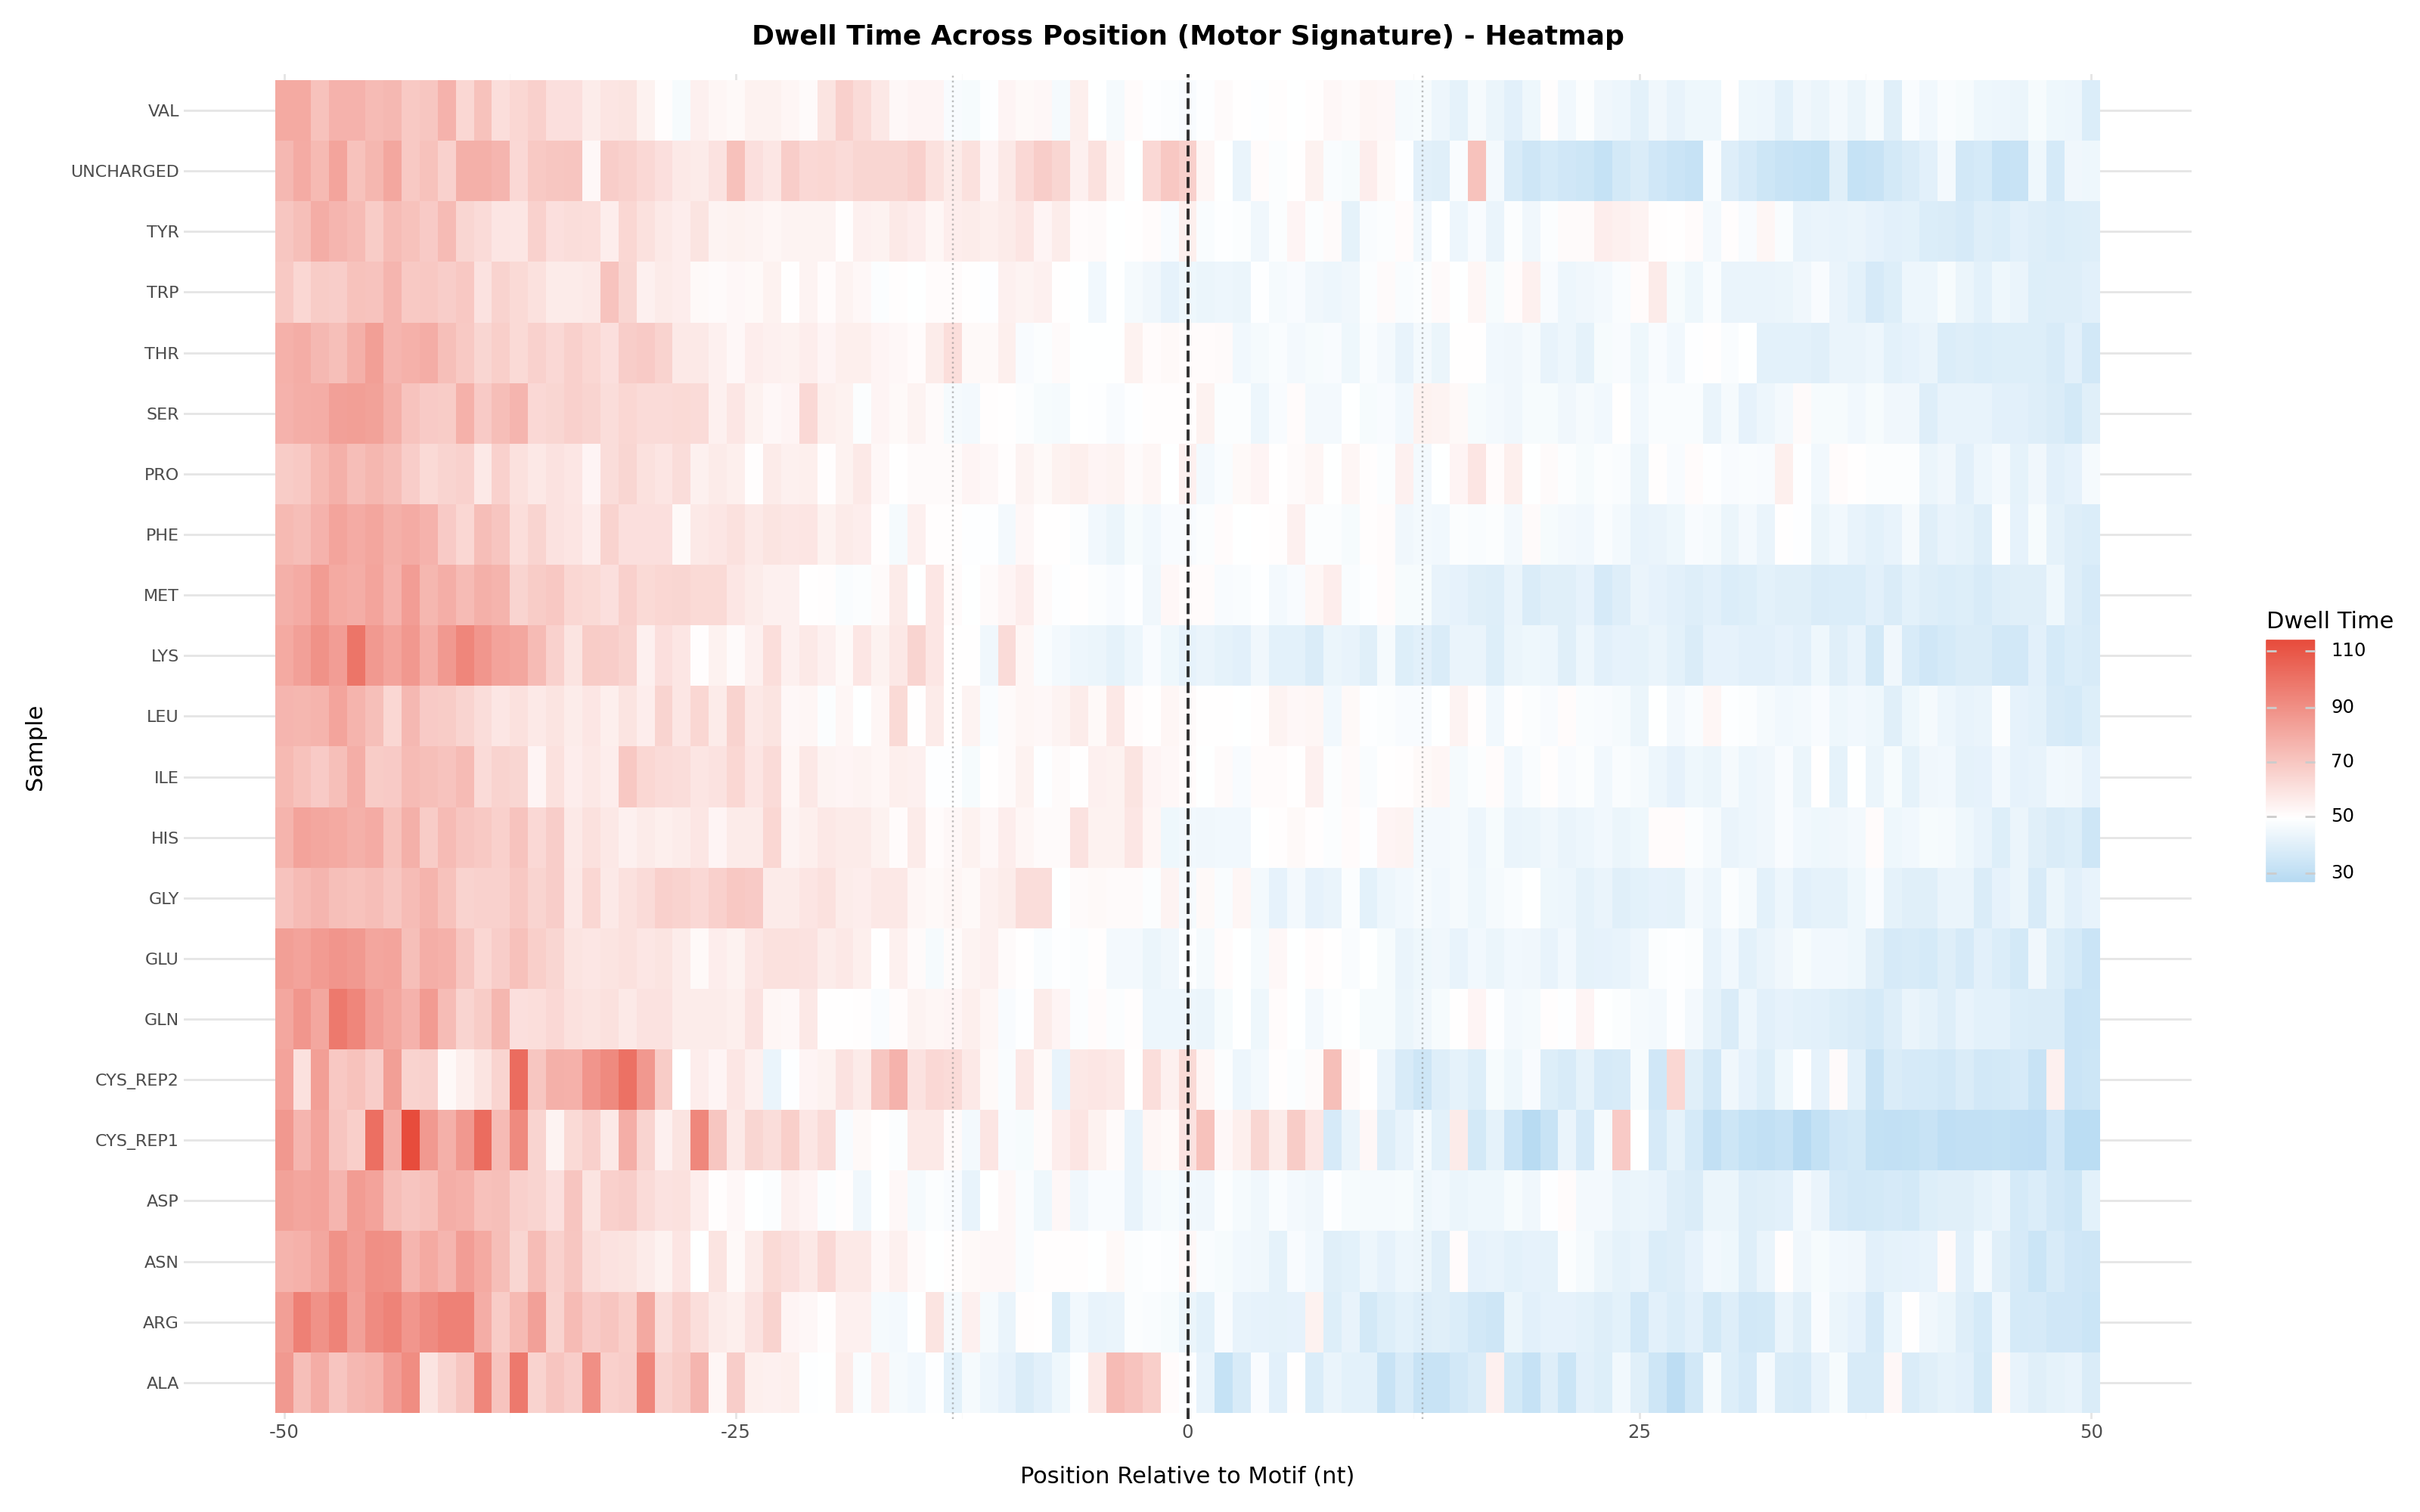

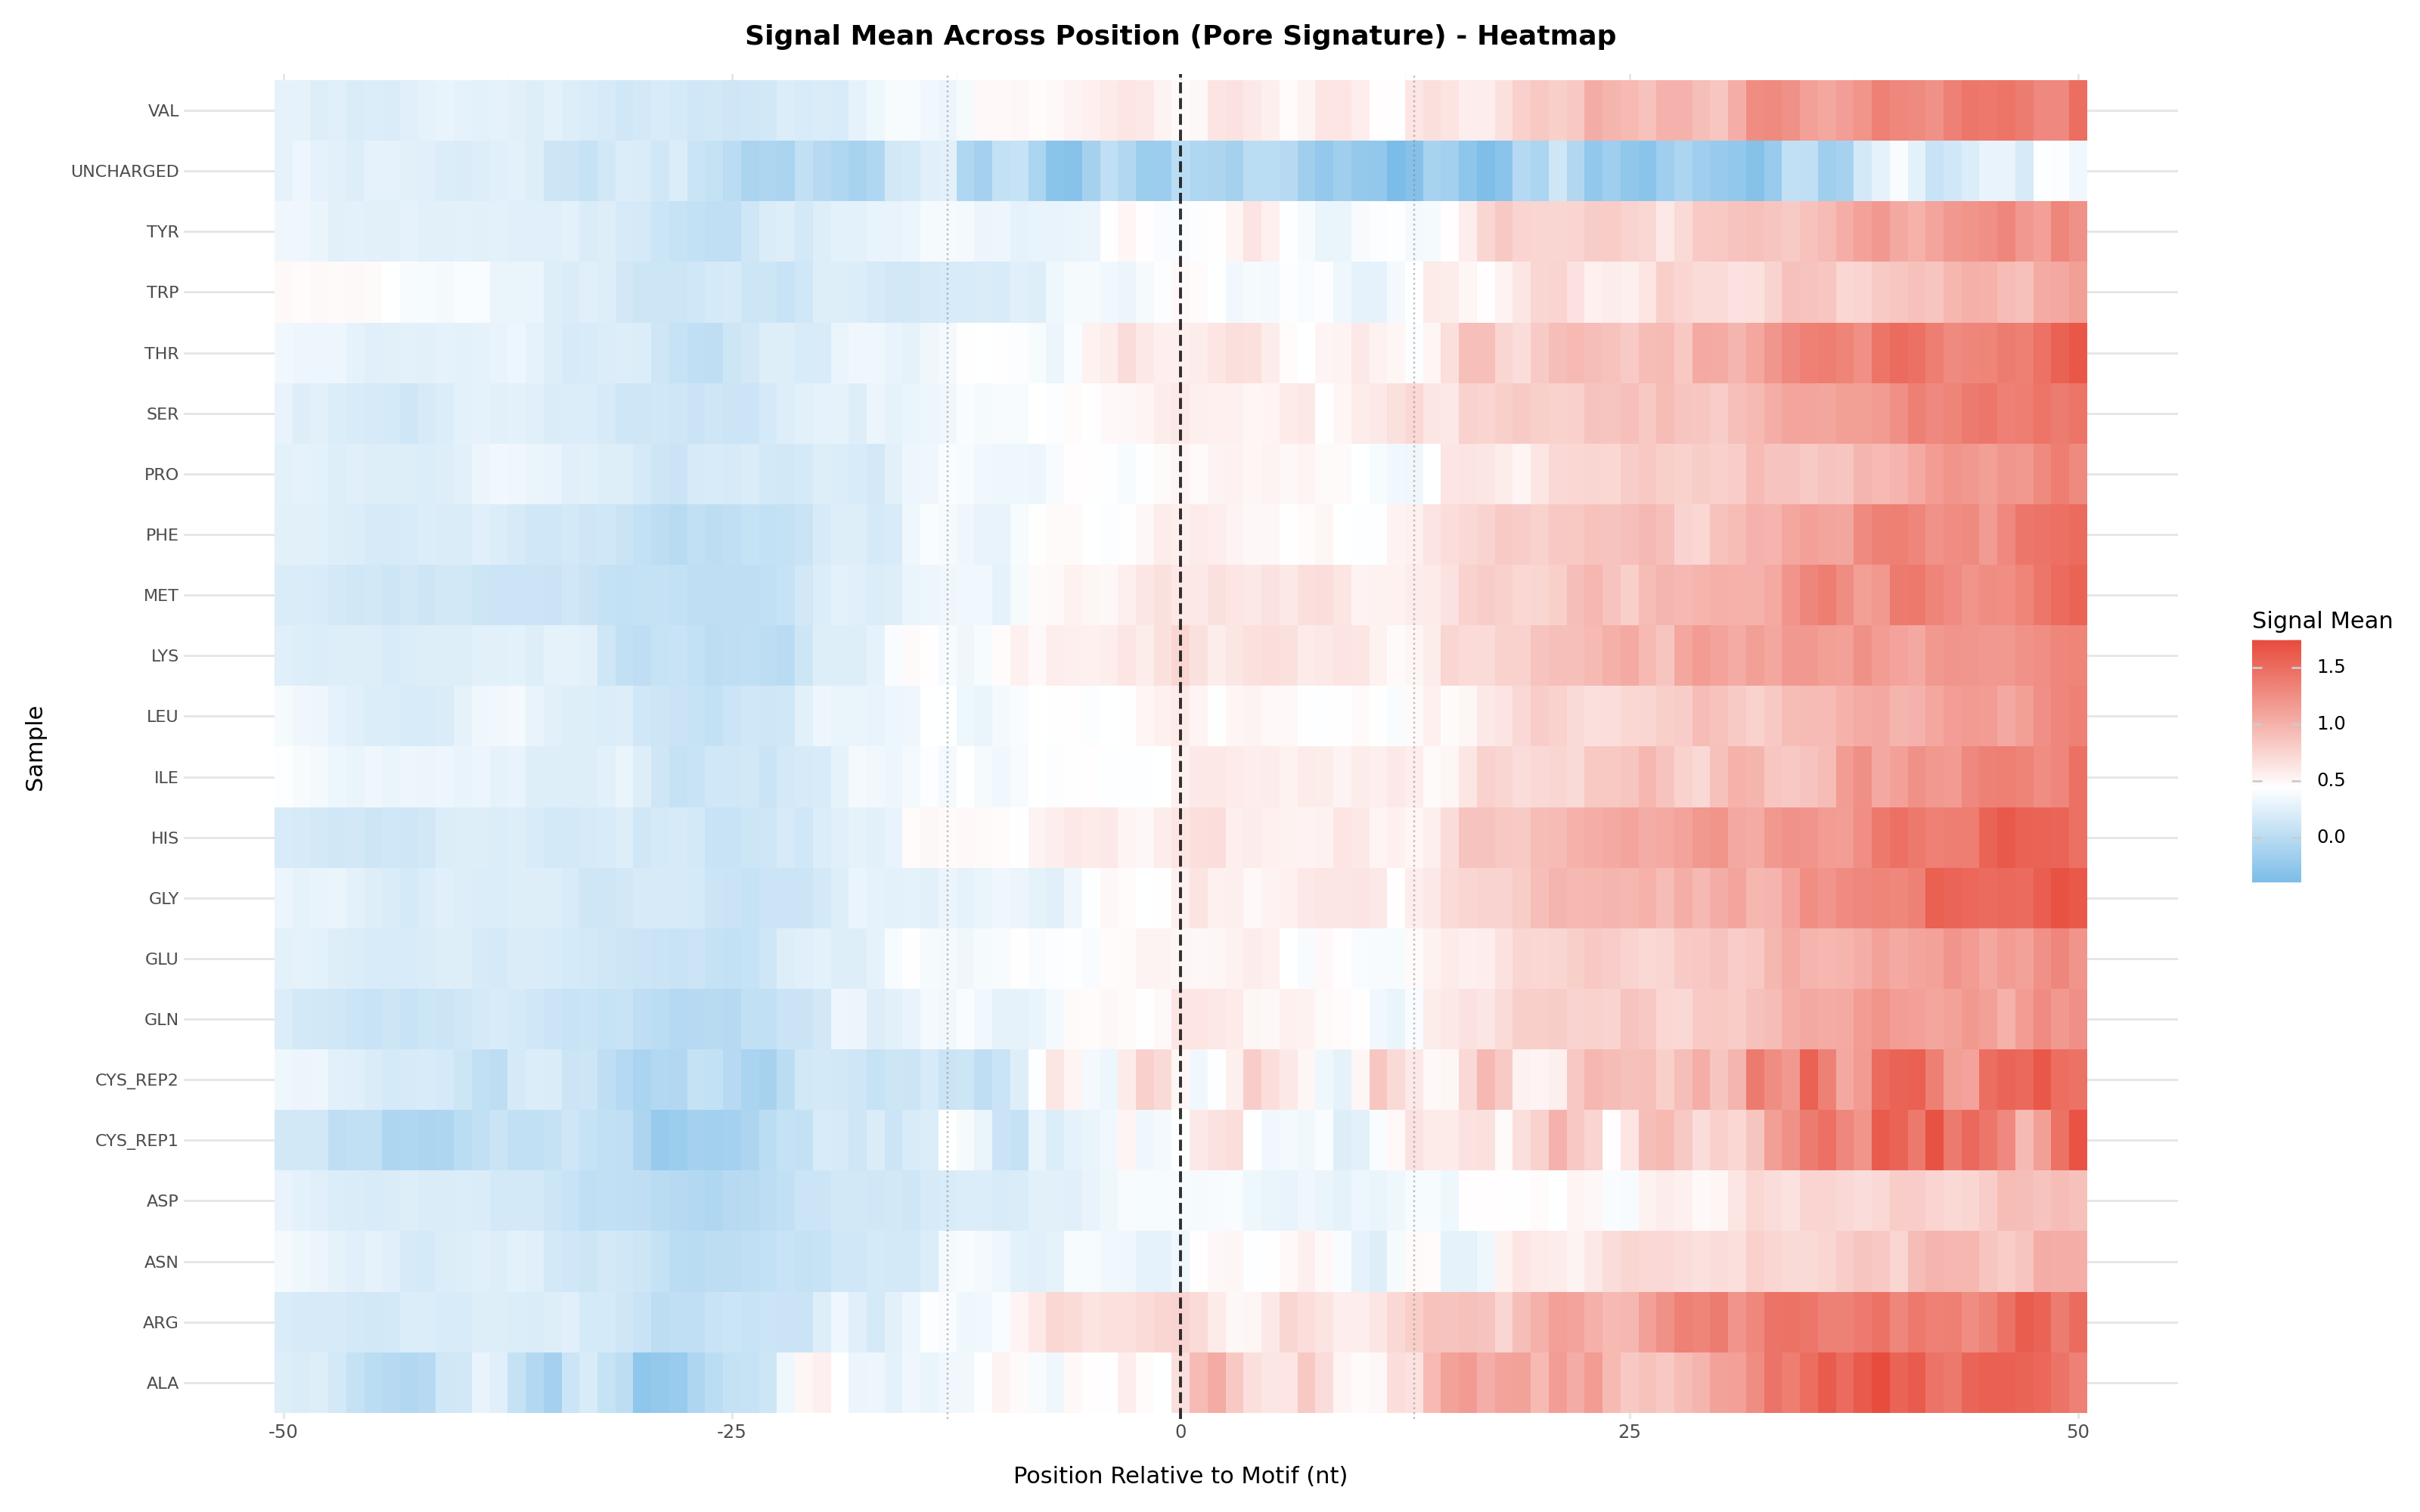

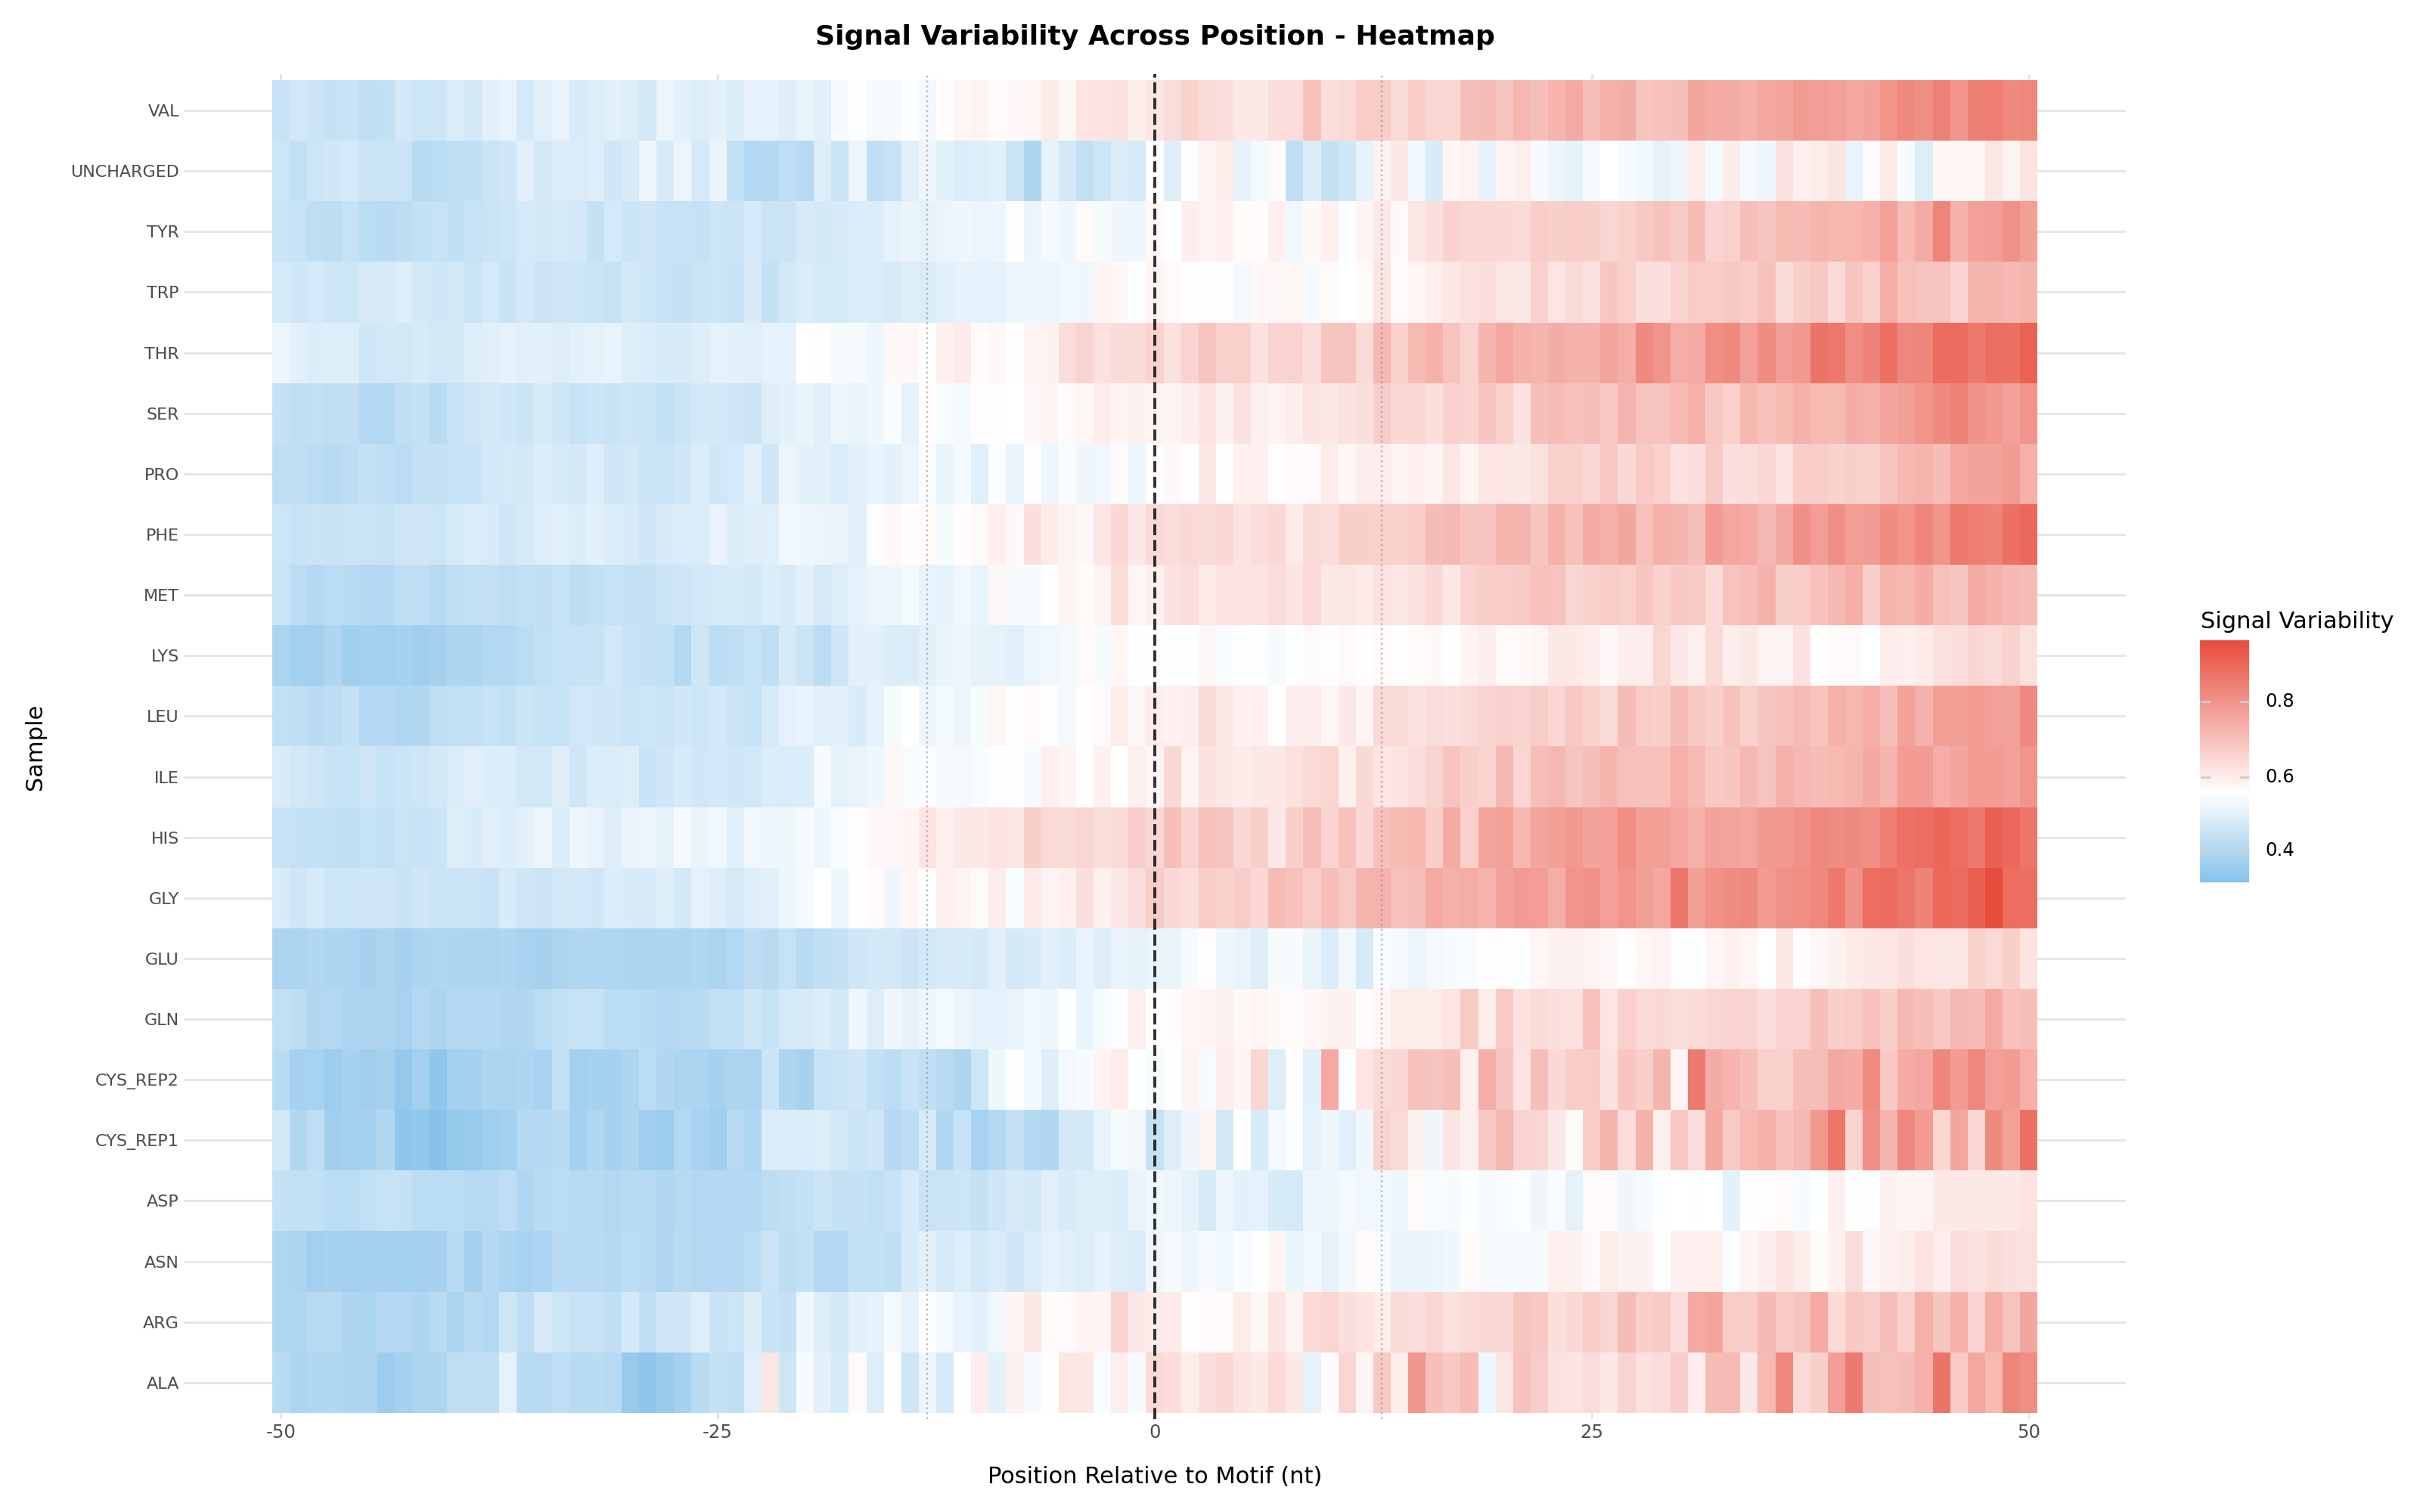


LINE PLOT: AVERAGE CHARGED VS UNCHARGED


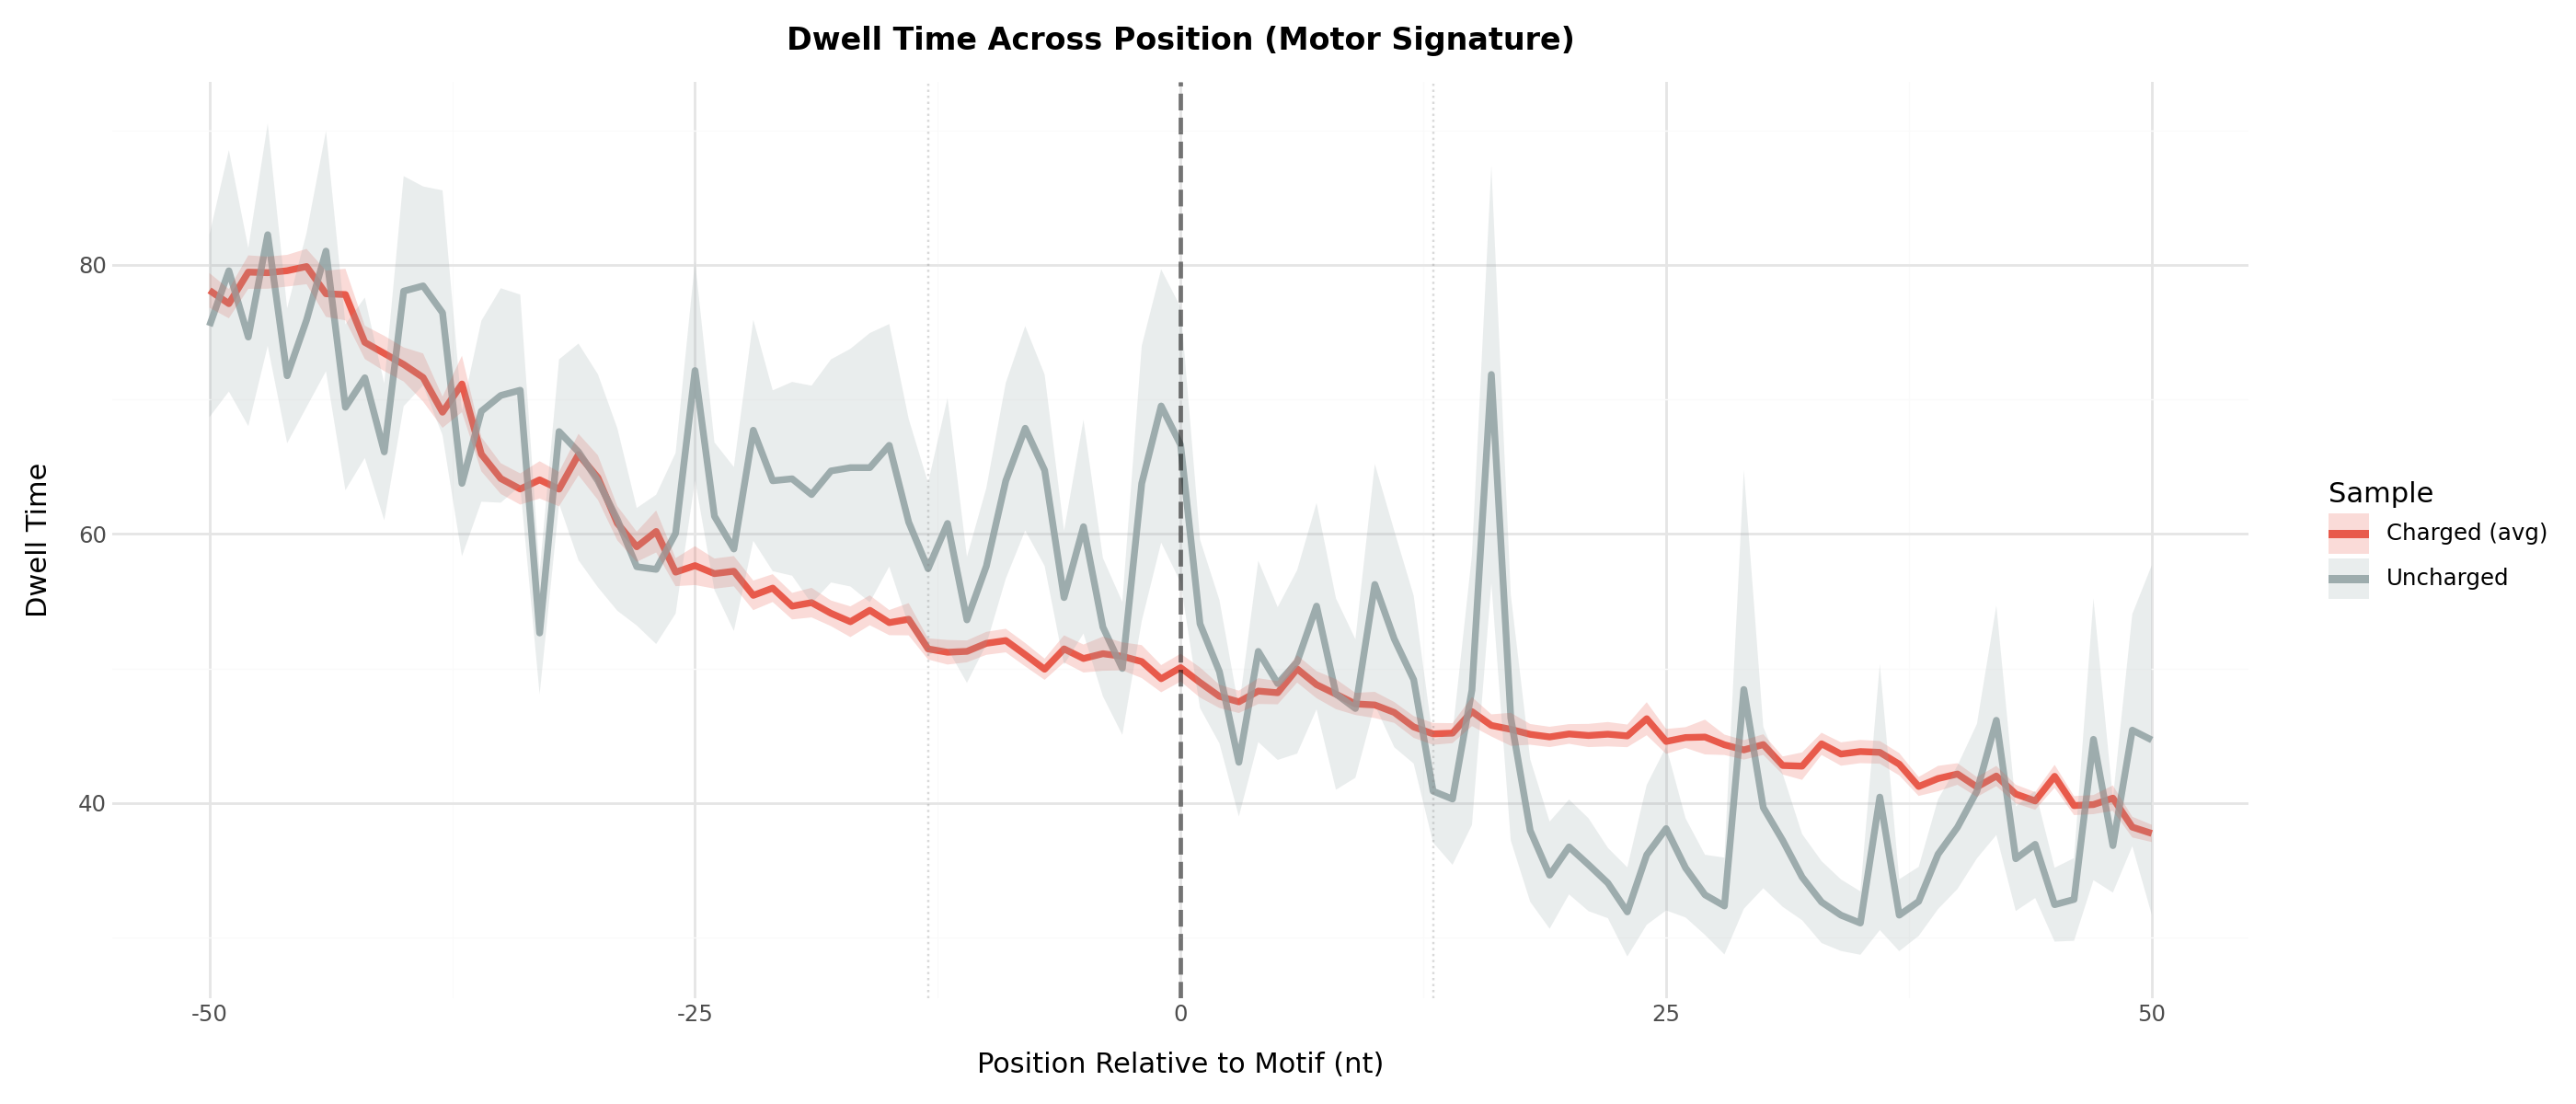

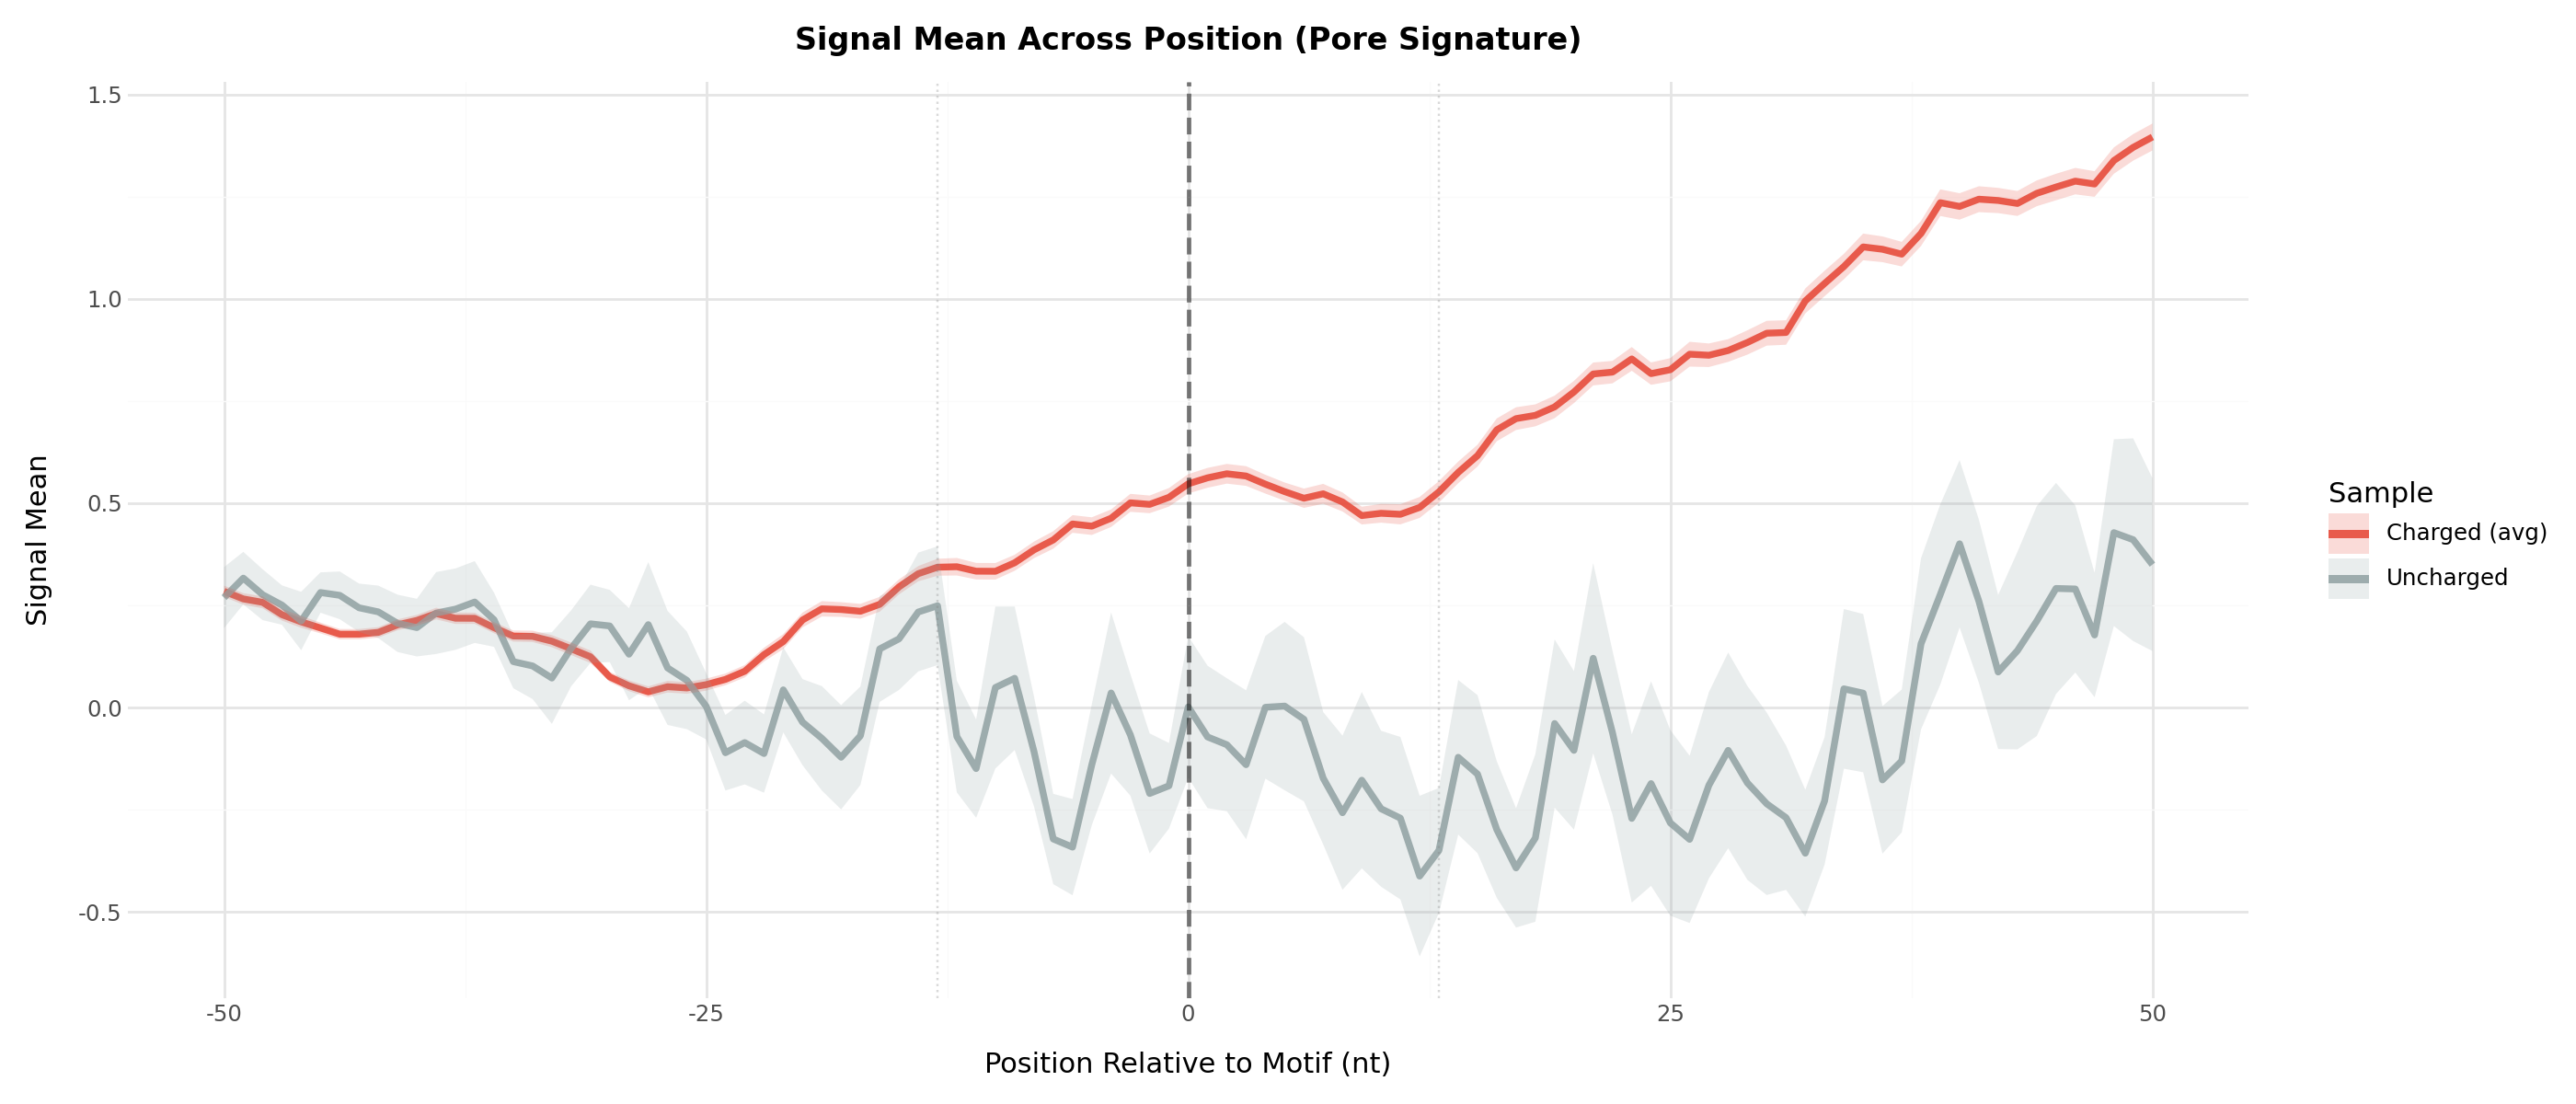

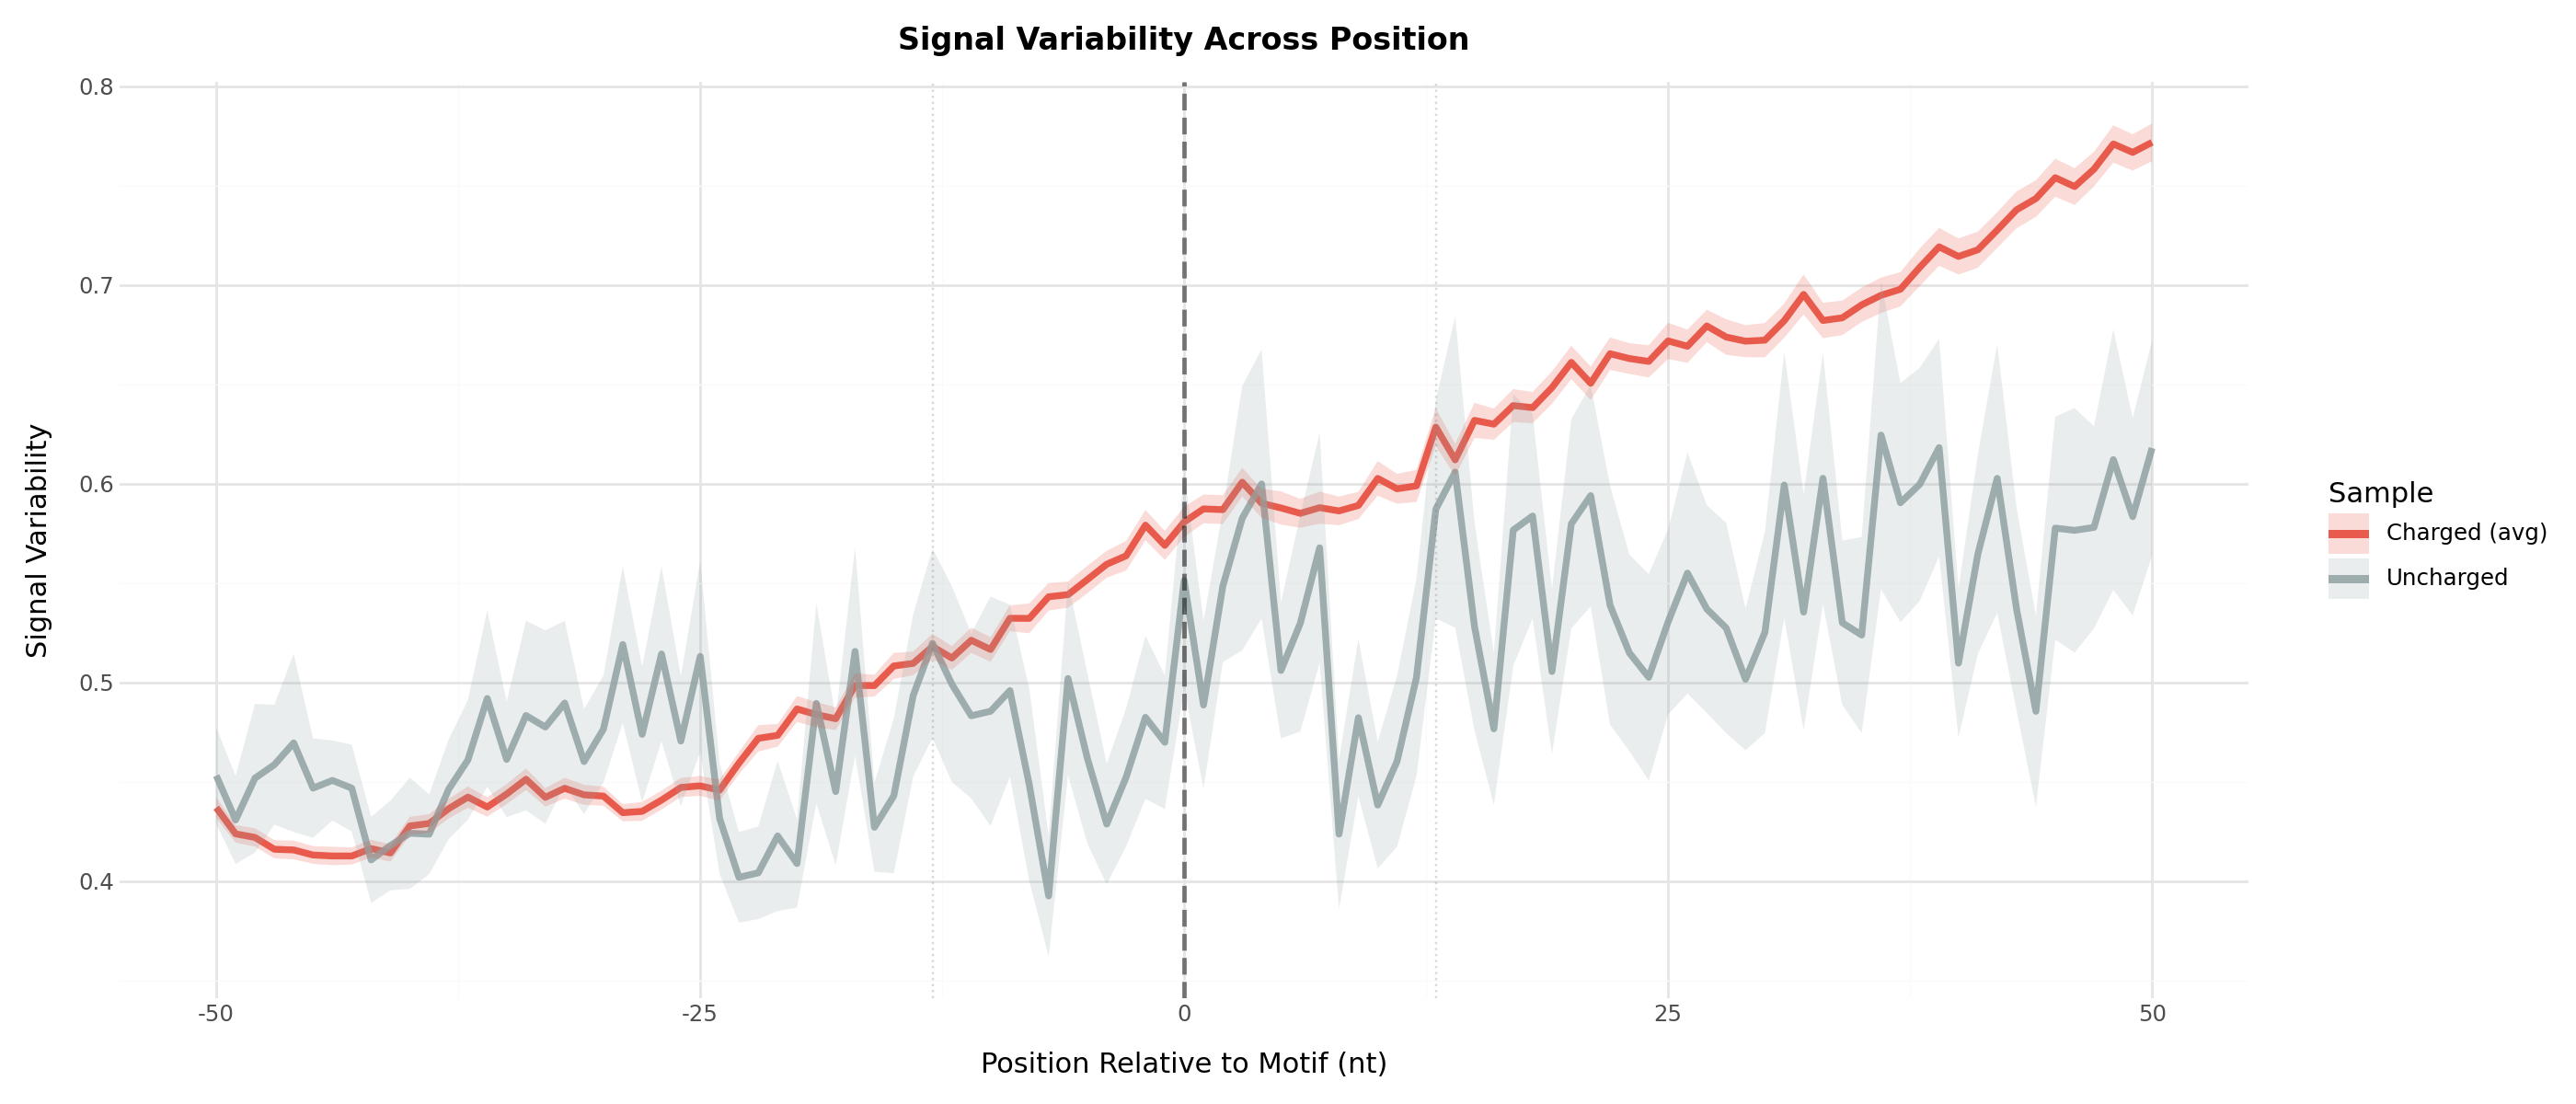

In [15]:
# Convert to pandas for plotting
stats_pd = all_stats.to_pandas()

# Create plots for each feature
features_to_plot = ["dwell_time", "signal_mean", "signal_variability"]
titles = {
    "dwell_time": "Dwell Time Across Position (Motor Signature)",
    "signal_mean": "Signal Mean Across Position (Pore Signature)",
    "signal_variability": "Signal Variability Across Position"
}

# === HEATMAPS: Show all amino acids at once ===
print("=" * 80)
print("HEATMAP VISUALIZATIONS")
print("=" * 80)

for feature in features_to_plot:
    feature_data = stats_pd[stats_pd["feature"] == feature].copy()

    # Clean up sample names for better display
    feature_data["sample"] = feature_data["label"].apply(
        lambda x: "UNCHARGED" if x == "uncharged" else x.replace("_synthetic", "").upper()
    )

    # Create heatmap
    plot = (
        p9.ggplot(feature_data, p9.aes(x="position", y="sample", fill="mean"))
        + p9.geom_tile()
        + p9.scale_fill_gradient2(
            low="#3498DB", mid="#FFFFFF", high="#E74C3C",
            midpoint=feature_data["mean"].median()
        )
        + p9.geom_vline(xintercept=0, linetype="dashed", color="black", alpha=0.8, size=0.8)
        + p9.geom_vline(xintercept=-13, linetype="dotted", color="gray", alpha=0.5)
        + p9.geom_vline(xintercept=13, linetype="dotted", color="gray", alpha=0.5)
        + p9.labs(
            title=f"{titles[feature]} - Heatmap",
            x="Position Relative to Motif (nt)",
            y="Sample",
            fill=feature.replace("_", " ").title()
        )
        + p9.theme_minimal()
        + p9.theme(
            figure_size=(16, 10),
            plot_title=p9.element_text(size=13, weight="bold"),
            axis_text_y=p9.element_text(size=8)
        )
    )

    plot.show()

# === LINE PLOTS: Uncharged vs all charged (averaged) ===
print("\n" + "=" * 80)
print("LINE PLOT: AVERAGE CHARGED VS UNCHARGED")
print("=" * 80)

for feature in features_to_plot:
    feature_data = stats_pd[stats_pd["feature"] == feature].copy()

    # Compute average across all charged samples
    charged_avg = feature_data[feature_data["label"] != "uncharged"].groupby("position").agg({
        "mean": "mean",
        "sem": lambda x: np.sqrt(np.sum(x**2)) / len(x)  # Combined SEM
    }).reset_index()
    charged_avg["label"] = "Charged (avg)"

    # Get uncharged data
    uncharged_data = feature_data[feature_data["label"] == "uncharged"][["position", "mean", "sem"]].copy()
    uncharged_data["label"] = "Uncharged"

    # Combine
    combined = pl.concat([
        pl.DataFrame(charged_avg),
        pl.DataFrame(uncharged_data)
    ]).to_pandas()

    plot = (
        p9.ggplot(combined, p9.aes(x="position", y="mean", color="label", fill="label"))
        + p9.geom_line(size=1.5, alpha=0.9)
        + p9.geom_ribbon(p9.aes(ymin="mean - sem", ymax="mean + sem"), alpha=0.2, color=None)
        + p9.geom_vline(xintercept=0, linetype="dashed", color="black", alpha=0.5, size=1)
        + p9.geom_vline(xintercept=-13, linetype="dotted", color="gray", alpha=0.3)
        + p9.geom_vline(xintercept=13, linetype="dotted", color="gray", alpha=0.3)
        + p9.scale_color_manual(values={"Charged (avg)": "#E74C3C", "Uncharged": "#95A5A6"})
        + p9.scale_fill_manual(values={"Charged (avg)": "#E74C3C", "Uncharged": "#95A5A6"})
        + p9.labs(
            title=titles[feature],
            x="Position Relative to Motif (nt)",
            y=feature.replace("_", " ").title(),
            color="Sample",
            fill="Sample"
        )
        + p9.theme_minimal()
        + p9.theme(
            figure_size=(14, 6),
            plot_title=p9.element_text(size=12, weight="bold"),
            legend_position="right"
        )
    )

    plot.show()

## Step 4: Difference Plots - Charged - Uncharged

Plot the difference (charged - uncharged) to highlight where signatures are strongest.

In [ ]:
# Compute differences (each charged - uncharged)
diff_data = []

# Get uncharged data for each feature
for feature in features_to_plot:
    feature_data = stats_pd[stats_pd["feature"] == feature]
    uncharged_data = feature_data[feature_data["label"] == "uncharged"].sort_values("position")

    # Compute difference for each charged amino acid
    for aa_sample in CHARGED_SAMPLES:
        aa_data = feature_data[feature_data["label"] == aa_sample].sort_values("position")

        if len(aa_data) == 0:
            continue

        positions = aa_data["position"].values
        diff = aa_data["mean"].values - uncharged_data["mean"].values

        for pos, d in zip(positions, diff, strict=False):
            diff_data.append({
                "position": pos,
                "feature": feature,
                "amino_acid": aa_sample,
                "difference": d
            })

diff_df = pl.DataFrame(diff_data).to_pandas()

# === DIFFERENCE HEATMAPS ===
print("=" * 80)
print("DIFFERENCE HEATMAPS (Charged - Uncharged)")
print("=" * 80)

for feature in features_to_plot:
    feature_diff = diff_df[diff_df["feature"] == feature].copy()

    # Clean up amino acid names
    feature_diff["aa"] = feature_diff["amino_acid"].apply(
        lambda x: x.replace("_synthetic", "").upper()
    )

    # Create heatmap
    plot = (
        p9.ggplot(feature_diff, p9.aes(x="position", y="aa", fill="difference"))
        + p9.geom_tile()
        + p9.scale_fill_gradient2(
            low="#3498DB", mid="#FFFFFF", high="#E74C3C",
            midpoint=0,
            limits=(-feature_diff["difference"].abs().max(), feature_diff["difference"].abs().max())
        )
        + p9.geom_vline(xintercept=0, linetype="dashed", color="black", alpha=0.8, size=0.8)
        + p9.geom_vline(xintercept=-13, linetype="dotted", color="black", alpha=0.5)
        + p9.geom_vline(xintercept=13, linetype="dotted", color="black", alpha=0.5)
        + p9.labs(
            title=f"{titles[feature]} - Difference from Uncharged",
            x="Position Relative to Motif (nt)",
            y="Amino Acid",
            fill=f"Δ {feature.replace('_', ' ').title()}"
        )
        + p9.theme_minimal()
        + p9.theme(
            figure_size=(16, 10),
            plot_title=p9.element_text(size=13, weight="bold"),
            axis_text_y=p9.element_text(size=8)
        )
    )

    plot.show()

# === AVERAGE DIFFERENCE LINE PLOT ===
print("\n" + "=" * 80)
print("AVERAGE DIFFERENCE (Mean across all amino acids)")
print("=" * 80)

for feature in features_to_plot:
    feature_diff = diff_df[diff_df["feature"] == feature].copy()

    # Compute average difference across all amino acids
    avg_diff = feature_diff.groupby("position").agg({
        "difference": ["mean", "std"]
    }).reset_index()
    avg_diff.columns = ["position", "mean", "std"]
    avg_diff["sem"] = avg_diff["std"] / np.sqrt(len(CHARGED_SAMPLES))

    plot = (
        p9.ggplot(avg_diff, p9.aes(x="position", y="mean"))
        + p9.geom_ribbon(p9.aes(ymin="mean - sem", ymax="mean + sem"), fill="#E74C3C", alpha=0.2)
        + p9.geom_line(color="#E74C3C", size=1.5, alpha=0.9)
        + p9.geom_hline(yintercept=0, linetype="solid", color="black", alpha=0.5, size=0.8)
        + p9.geom_vline(xintercept=0, linetype="dashed", color="black", alpha=0.5, size=1)
        + p9.geom_vline(xintercept=-13, linetype="dotted", color="gray", alpha=0.3)
        + p9.geom_vline(xintercept=13, linetype="dotted", color="gray", alpha=0.3)
        + p9.labs(
            title=f"{titles[feature]} - Average Difference",
            x="Position Relative to Motif (nt)",
            y=f"Δ {feature.replace('_', ' ').title()}\n(Charged - Uncharged, mean ± SEM)"
        )
        + p9.theme_minimal()
        + p9.theme(
            figure_size=(14, 6),
            plot_title=p9.element_text(size=12, weight="bold")
        )
    )

    plot.show()

## Step 5: Peak Detection - Measure Offset

Automatically detect where dwell and current signatures peak, then calculate the offset.

In [ ]:
def find_signature_peak(diff_df, feature, amino_acid, window=(-20, 20)):
    """
    Find the position of maximum absolute difference for a feature.

    Args:
        diff_df: DataFrame with position and difference columns
        feature: Feature name to analyze
        amino_acid: Amino acid sample name
        window: (min_pos, max_pos) to search within

    Returns:
        dict with peak_position, peak_value, peak_type
    """
    feature_diff = diff_df[
        (diff_df["feature"] == feature) &
        (diff_df["amino_acid"] == amino_acid) &
        (diff_df["position"] >= window[0]) &
        (diff_df["position"] <= window[1])
    ].copy()

    if len(feature_diff) == 0:
        return None

    # Find position of maximum absolute difference
    feature_diff["abs_diff"] = feature_diff["difference"].abs()
    peak_idx = feature_diff["abs_diff"].idxmax()

    peak_row = feature_diff.loc[peak_idx]

    return {
        "amino_acid": amino_acid,
        "feature": feature,
        "peak_position": int(peak_row["position"]),
        "peak_value": float(peak_row["difference"]),
        "peak_type": "increase" if peak_row["difference"] > 0 else "decrease",
    }


# Detect peaks for each amino acid and feature
print("=" * 80)
print("PEAK DETECTION - SIGNATURE LOCALIZATION")
print("=" * 80)

all_peaks = []

for aa_sample in CHARGED_SAMPLES:
    print(f"\n{aa_sample.upper().replace('_SYNTHETIC', '')}:")
    aa_peaks = {}

    for feature in features_to_plot:
        peak_info = find_signature_peak(diff_df, feature, aa_sample, window=(-25, 25))
        if peak_info:
            all_peaks.append(peak_info)
            aa_peaks[feature] = peak_info

            print(f"  {feature}:")
            print(f"    Peak at position: {peak_info['peak_position']:+d} nt")
            print(f"    Peak value:       {peak_info['peak_value']:+.4f}")

    # Calculate offset for this amino acid
    if "dwell_time" in aa_peaks and "signal_mean" in aa_peaks:
        dwell_peak = aa_peaks["dwell_time"]["peak_position"]
        signal_peak = aa_peaks["signal_mean"]["peak_position"]
        measured_offset = abs(dwell_peak - signal_peak)

        print(f"  Measured offset: {measured_offset} nt (dwell={dwell_peak:+d}, current={signal_peak:+d})")

peaks_df = pl.DataFrame(all_peaks)

# Summary table of offsets
print("\n" + "=" * 80)
print("OFFSET SUMMARY ACROSS AMINO ACIDS")
print("=" * 80)

offset_summary = []
for aa_sample in CHARGED_SAMPLES:
    aa_peaks_df = peaks_df.filter(pl.col("amino_acid") == aa_sample)

    dwell_peaks = aa_peaks_df.filter(pl.col("feature") == "dwell_time")
    signal_peaks = aa_peaks_df.filter(pl.col("feature") == "signal_mean")

    if len(dwell_peaks) > 0 and len(signal_peaks) > 0:
        dwell_pos = dwell_peaks["peak_position"][0]
        signal_pos = signal_peaks["peak_position"][0]
        offset = abs(dwell_pos - signal_pos)

        offset_summary.append({
            "amino_acid": aa_sample.replace("_synthetic", "").upper(),
            "dwell_peak": dwell_pos,
            "current_peak": signal_pos,
            "offset_nt": offset
        })

offset_summary_df = pl.DataFrame(offset_summary)
print(offset_summary_df)

# Calculate mean offset
mean_offset = offset_summary_df["offset_nt"].mean()
std_offset = offset_summary_df["offset_nt"].std()

print(f"\n➤ MEAN OFFSET: {mean_offset:.1f} ± {std_offset:.1f} nt")
print("  Expected: ~12-13 nt")

if mean_offset >= 10 and mean_offset <= 15:
    print("\n✓ Measured offset is consistent with expected ~12-13 nt!")
else:
    print("\n⚠️  Measured offset differs from expected ~12-13 nt")

# Save measurements
offset_report = {
    "mean_offset_nt": float(mean_offset),
    "std_offset_nt": float(std_offset),
    "per_amino_acid": offset_summary_df.to_dicts(),
    "expected_offset_nt": "12-13",
}

import json

with open(OUTPUT_DIR / "offset_measurements.json", "w") as f:
    json.dump(offset_report, f, indent=2)

print(f"\n✓ Saved: {OUTPUT_DIR / 'offset_measurements.json'}")

## Step 6: Heatmap Visualization

Create a 2D heatmap showing all features across position for charged vs uncharged.

In [ ]:
# === OFFSET ANNOTATION HEATMAP ===
# Show where dwell and current peaks are for each amino acid

print("=" * 80)
print("PEAK POSITION HEATMAP")
print("=" * 80)

# Create a summary showing peak positions for each amino acid
peak_position_data = []

for aa_sample in CHARGED_SAMPLES:
    aa_peaks_df = peaks_df.filter(pl.col("amino_acid") == aa_sample)

    if len(aa_peaks_df) == 0:
        continue

    aa_name = aa_sample.replace("_synthetic", "").upper()

    for feature in ["dwell_time", "signal_mean"]:
        feature_peak = aa_peaks_df.filter(pl.col("feature") == feature)
        if len(feature_peak) > 0:
            peak_position_data.append({
                "amino_acid": aa_name,
                "feature": "Dwell" if feature == "dwell_time" else "Current",
                "peak_position": feature_peak["peak_position"][0]
            })

if len(peak_position_data) > 0:
    peak_pos_df = pl.DataFrame(peak_position_data).to_pandas()

    plot = (
        p9.ggplot(peak_pos_df, p9.aes(x="feature", y="amino_acid", fill="peak_position"))
        + p9.geom_tile(color="white", size=0.5)
        + p9.geom_text(p9.aes(label="peak_position"), size=8, color="black")
        + p9.scale_fill_gradient2(
            low="#3498DB", mid="#FFFFFF", high="#E74C3C",
            midpoint=0
        )
        + p9.labs(
            title="Peak Positions: Dwell vs Current Signatures",
            x="Signature Type",
            y="Amino Acid",
            fill="Position (nt)"
        )
        + p9.theme_minimal()
        + p9.theme(
            figure_size=(6, 12),
            plot_title=p9.element_text(size=13, weight="bold"),
            axis_text_y=p9.element_text(size=8)
        )
    )

    plot.show()
else:
    print("No peak position data available yet (run peak detection cell first)")

## Step 7: Cross-Correlation Analysis

Compute cross-correlation between dwell and current difference signals to quantify the offset.

In [ ]:
# Compute cross-correlation for each amino acid
print("=" * 80)
print("CROSS-CORRELATION ANALYSIS")
print("=" * 80)

cross_corr_results = []

for aa_sample in CHARGED_SAMPLES:
    # Extract difference signals for this amino acid
    dwell_diff = diff_df[
        (diff_df["feature"] == "dwell_time") &
        (diff_df["amino_acid"] == aa_sample)
    ].sort_values("position")

    signal_diff = diff_df[
        (diff_df["feature"] == "signal_mean") &
        (diff_df["amino_acid"] == aa_sample)
    ].sort_values("position")

    if len(dwell_diff) == 0 or len(signal_diff) == 0:
        continue

    # Compute cross-correlation
    correlation = sp_signal.correlate(
        dwell_diff["difference"],
        signal_diff["difference"],
        mode="full"
    )
    lags = sp_signal.correlation_lags(
        len(dwell_diff["difference"]),
        len(signal_diff["difference"]),
        mode="full"
    )

    # Find peak correlation
    peak_idx = np.argmax(np.abs(correlation))
    peak_lag = lags[peak_idx]
    peak_corr = correlation[peak_idx]

    aa_name = aa_sample.replace("_synthetic", "").upper()
    print(f"\n{aa_name}:")
    print(f"  Peak correlation: {peak_corr:.4f}")
    print(f"  Peak lag:         {peak_lag} positions")

    cross_corr_results.append({
        "amino_acid": aa_name,
        "peak_lag": peak_lag,
        "peak_correlation": peak_corr
    })

# Summary
print("\n" + "=" * 80)
print("CROSS-CORRELATION SUMMARY")
print("=" * 80)
cross_corr_df = pl.DataFrame(cross_corr_results)
print(cross_corr_df)

mean_lag = cross_corr_df["peak_lag"].mean()
print(f"\n➤ MEAN LAG: {mean_lag:.1f} positions")
print(f"  Interpretation: Dwell signal is shifted by ~{mean_lag:.0f} positions relative to current signal")

## Summary and Recommendations

Based on the analysis above, we can now make data-driven decisions about implementing offset correction.

In [ ]:
print("=" * 80)
print("SUMMARY & RECOMMENDATIONS")
print("=" * 80)

print(f"\n1. MEASURED OFFSET ACROSS {len(CHARGED_SAMPLES)} AMINO ACIDS:")
print(f"   Mean offset: {mean_offset:.1f} ± {std_offset:.1f} nt")
print("   Expected:    ~12-13 nt")
print("\n   Per amino acid:")
for row in offset_summary_df.to_dicts():
    print(f"     {row['amino_acid']:3s}: {row['offset_nt']:2d} nt (dwell={row['dwell_peak']:+3d}, current={row['current_peak']:+3d})")

print("\n2. BIOLOGICAL INTERPRETATION:")
print("   The consistent offset across different amino acids suggests:")
print("   • Motor-pore offset is a structural property of the nanopore")
print("   • Not dependent on specific amino acid chemistry")
print("   • Should apply universally to all aa-tRNA modifications")

print("\n3. IMPLEMENTATION RECOMMENDATIONS:")
print("\n   A. IMMEDIATE ACTION:")
print("      Modify chunking/extractor.py to extract features from offset windows")
print(f"      - Use mean dwell offset: ~{mean_offset:.0f} nt")
print("      - Extract dwell and current features from different genomic positions")

print("\n   B. CONFIGURATION:")
print("      Add parameters to constants.py or config:")
print(f"      - MOTOR_PORE_OFFSET = {int(mean_offset)}")
print("      - Apply offset when extracting dwell-based features")

print("\n   C. MODEL ARCHITECTURE:")
if mean_offset > 10:
    print("      Option 1 (Recommended): Offset-aware feature extraction")
    print("        - Extract dwell features from base_idx + offset")
    print("        - Extract current features from base_idx")
    print("        - Keep current model architecture")
    print("")
    print("      Option 2: Wider context window")
    print(f"        - Use context ±{int(mean_offset) + 5} nt to capture both signatures")
    print("        - Let convolutions/attention learn the offset")

print("\n   D. VALIDATION:")
print("      1. Implement offset-corrected feature extraction")
print("      2. Prepare new training data with corrected offsets")
print("      3. Retrain ConvLSTMDwell model")
print("      4. Compare accuracy: baseline vs offset-aware")
print("      5. EXPECT: Significant improvement in dwell feature contribution")

print("\n4. NEXT STEPS:")
print("   [ ] Implement offset correction in chunking/extractor.py")
print("   [ ] Update prepare command to support --motor-pore-offset")
print("   [ ] Regenerate training data with offset correction")
print("   [ ] Retrain all models with corrected features")
print("   [ ] Benchmark old vs new models")
print("   [ ] Update documentation in issue #81")

print("\n" + "=" * 80)

## FINDINGS: Signal Orientation Investigation

**Date**: 2025-01-16

### Investigation Summary

We investigated whether POD5 signal orientation (3' → 5' collection order) matches BAM sequence orientation (5' → 3' reporting), as this could explain unexpected dwell time signatures.

### Diagnostic Results

#### 1. Signal Orientation Diagnostic ()

**Test 1: Move Table Monotonicity**


**Conclusion**: Signal orientation is CORRECT. No reversal needed.

**Test 2: Visual Alignment Check**
- Signal quality varies widely between reads
- Some reads show very noisy/flat signal even with MAPQ ≥ 60
- Difficult to visually confirm base-to-signal alignment
- **Interpretation**: Data quality issue, not orientation issue

#### 2. Motor-Pore Offset Analysis (this notebook)

**Dwell Time Signatures**:
- **Blue stripe at position +16**: Amino acids DECREASE dwell time at +16 nt
- Consistent across most amino acids (ARG, ASN, CYS_REP2, GLU, GLY, MET)
- Peak magnitude: -20 to -30 samples/nt
- **This is real, not an artifact of signal reversal**

**Current (Signal Mean) Signatures**:
- ⚠️ **CRITICAL BUG DISCOVERED**: All signal_mean and signal_variability features are ZERO
- Peak detection shows all "current peaks" at -25 (edge of window) with value 0.0
- Cross-correlation yields 0.0 for all amino acids
- **Root cause**:  is not extracting features correctly

### Interpretation

#### Why Blue (Decreased) Dwell Time?

Since signal orientation is correct, the blue stripe at +16 represents a real biological effect. Possible explanations:

1. **Motor speeds up**: Amino acid in motor causes DECREASED dwell time (counterintuitive but possible)
2. **Complex multi-position effect**: Amino acid affects dwell time at multiple positions
3. **Normalization/baseline issue**: The "uncharged" control might not be a proper baseline

#### Critical Bug: Zero Signal Features

The  function in  is returning all zeros. This prevents us from:
- Identifying where current (pore) signatures occur
- Measuring the motor-pore offset
- Validating the expected ~12-13 nt offset

**Need to investigate**: 
- Is  producing all zeros?
- Is the seq-to-sig mapping correct?
- Are we indexing the normalized signal array correctly?

### Next Steps

#### Immediate (Critical)
1. **Debug ** - Fix the zero features bug
2. **Verify signal extraction** - Ensure raw signal → normalized signal → features pipeline works
3. **Re-run offset analysis** - Once signal features are fixed

#### After Bug Fix
4. **Locate current signature** - Find where signal_mean changes (expected at position ~0)
5. **Measure offset** - Distance between dwell peak (+16?) and current peak (~0?) 
6. **Validate offset** - Compare measured offset to expected 12-13 nt
7. **Interpret decreased dwell** - Understand why amino acids decrease (not increase) dwell time

#### Implementation
8. **Implement offset correction** - Once we know the true offset
9. **Regenerate training data** - With offset-aware feature extraction
10. **Retrain models** - Expect improved performance with corrected features

### Key Findings

✅ **Signal orientation is correct** - No need to reverse POD5 signal

✅ **Dwell time signatures are real** - Blue stripe at +16 is a genuine biological effect

⚠️ **Current signatures are broken** -  returns all zeros (BUG)

❓ **Biological mechanism unclear** - Why do amino acids *decrease* dwell time?

🔧 **Action required**: Debug and fix signal feature extraction before continuing offset analysis
